# ARIMAX

In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Modelo

In [ ]:
from itertools import product

def fit_best_sarimax(df_daily, df_weekly, contaminante, y_transform=None, inverse_transform=None):
   
    def fit_model(df, freq_label):
        """Ajusta SARIMAX para un dataframe (diario o semanal), buscando mejores hyperparametros."""

        Y_orig = df[contaminante]
        X = df[['TOUT','RH','SR','PRS']]

        # Aplicar transformación a la variable contaminante si se especifica
        if y_transform is not None:
            Y = y_transform(Y_orig)
        else:
            Y = Y_orig

        # split
        split = int(len(df)*0.8)
        Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]
        Y_train_orig, Y_test_orig = Y_orig.iloc[:split], Y_orig.iloc[split:]
        X_train, X_test = X.iloc[:split], X.iloc[split:]

        # scaler sin leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # buscar mejores hiperparámetros (order)
        best_aic = np.inf
        best_result = None
        best_order = None

        # rangos - p = [1,2,3], d = [0,1], q = [1,2,3]
        for order in product([1,2,3,4,5,6,7,8,9,10], [0,1], [1,2,3,4,5,6,7,8,9,10]):
            try:
                model = SARIMAX(
                    Y_train,
                    exog=X_train_scaled,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                results = model.fit(disp=False)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_result = results
                    best_order = order
            except Exception as e:
                continue  # ignora combinaciones que no convergen, etc.

        # predicciones con mejores parámetros (en espacio transformado)
        pred_trans = best_result.predict(start=len(Y_train), end=len(Y)-1, exog=X_test_scaled)
        # Invertir la transformación si corresponde, para comparar en escala original
        if inverse_transform is not None and y_transform is not None:
            pred = inverse_transform(pred_trans)
        else:
            pred = pred_trans

        # En todos los casos las métricas se calculan en escala original
        mae  = mean_absolute_error(Y_test_orig, pred)
        rmse = np.sqrt(mean_squared_error(Y_test_orig, pred))
        r2   = r2_score(Y_test_orig, pred)
        # Nueva métrica: MAPE
        mape = np.mean(np.abs((Y_test_orig - pred) / Y_test_orig)) * 100

        # residual diagnostics (trabajo en espacio transformado)
        resid = best_result.resid
        lb_p = sm.stats.acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
        jb_p = sm.stats.jarque_bera(resid)[1]

        # ranking importancia
        coefs = best_result.params.filter(regex='^x')
        coef_table = pd.DataFrame({
            'Variable': X.columns,
            'Coef': coefs.values,
            'AbsImpact': np.abs(coefs.values),
            'Pvalue': best_result.pvalues.filter(regex='^x').values
        }).sort_values('AbsImpact', ascending=False)

        summary = {
            "freq": freq_label,
            "AIC": best_aic,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "R2": r2,
            "LjungBox_p": lb_p,
            "JarqueBera_p": jb_p,
            "coef_table": coef_table,
            "results": best_result,
            "scaler": scaler,
            "Y_test": Y_test_orig,
            "pred": pred,
            "best_order": best_order,
            "y_transform": y_transform,
            "inverse_transform": inverse_transform,
        }

        return summary
    
    # --- Ajustar ambos modelos ---
    daily_model  = fit_model(df_daily,  "Diario")
    weekly_model = fit_model(df_weekly, "Semanal")

    # --- Selección automática ---
    #best = daily_model if daily_model["R2"] > weekly_model["R2"] else weekly_model
    best_daily = daily_model
    best_weekly = weekly_model

    return {
        "best_daily": best_daily,
        "best_weekly": best_weekly,
        "daily": daily_model,
        "weekly": weekly_model
    }
    
def plot_diagnostics(result_dict):
    results = result_dict["results"]
    resid = results.resid

    # residuales
    plt.figure(figsize=(12,4))
    plt.plot(resid)
    plt.axhline(0, color="black")
    plt.title("Residuales")
    plt.show()

    # ACF / PACF
    fig, ax = plt.subplots(1,2, figsize=(14,4))
    sm.graphics.tsa.plot_acf(resid, ax=ax[0], lags=40)
    sm.graphics.tsa.plot_pacf(resid, ax=ax[1], lags=40)
    plt.show()

    # QQ plot
    sm.qqplot(resid, line='45')
    plt.title("QQ Plot")
    plt.show()

    # Hist residual
    plt.hist(resid, bins=30, edgecolor='black')
    plt.title("Histograma de residuales")
    plt.show()


# CENTRO

## data

In [ ]:
# Estandarizar columnas relevantes en 'centro'
CENTRO = pd.read_csv("df_CENTRO_22_25.csv")
CENTRO["PM10_std"] = (CENTRO["PM10"] - CENTRO["PM10"].mean()) / CENTRO["PM10"].std()
CENTRO["PM2.5_std"] = (CENTRO["PM2.5"] - CENTRO["PM2.5"].mean()) / CENTRO["PM2.5"].std()
CENTRO["NO_std"] = (CENTRO["NO"] - CENTRO["NO"].mean()) / CENTRO["NO"].std()
CENTRO["NO2_std"] = (CENTRO["NO2"] - CENTRO["NO2"].mean()) / CENTRO["NO2"].std()
CENTRO["SO2_std"] = (CENTRO["SO2"] - CENTRO["SO2"].mean()) / CENTRO["SO2"].std()
CENTRO["O3_std"] = (CENTRO["O3"] - CENTRO["O3"].mean()) / CENTRO["O3"].std()  # Agrega estandarización de O3

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
CENTRO["Y_1"] = CENTRO["O3_std"]
CENTRO["PM10"] = CENTRO["PM10"]
CENTRO["PM2.5"] = CENTRO["PM2.5"]
CENTRO["Y_3"] = CENTRO[["NO_std", "NO2_std"]].mean(axis=1)
CENTRO["Y_4"] = CENTRO["SO2"] 
# Incluye la columna "date" en el DataFrame resultado
centro_Y = CENTRO[["date", "Y_1","PM10", "PM2.5", "Y_3", "Y_4","TOUT", "RH", "SR", "PRS", "WSR", "WDR"]]


# --- Diario: ozono ('Y_1') con máximo, el resto con promedio ---
df_Centro_diario = centro_Y.copy()
df_Centro_diario['date'] = pd.to_datetime(df_Centro_diario['date'])
df_Centro_diario = df_Centro_diario.set_index('date')
df_Y_diario = df_Centro_diario.resample("D").mean()

# --- Semanal: ozono ('Y_1') con máximo semanal, resto promedio ---
df_Centro_semanal = centro_Y.copy()
df_Centro_semanal['date'] = pd.to_datetime(df_Centro_semanal['date'])
df_Centro_semanal = df_Centro_semanal.set_index('date')
df_Y_semanal = df_Centro_semanal.resample("W").mean()
df_Y_semanal.describe().T


,count,mean,std,min,25%,50%,75%,max
Y_1,184.0,-0.002414,0.399573,-0.959054,-0.225114,-0.062725,0.230668,1.053054
PM10,184.0,60.887836,18.415288,18.291667,47.709821,59.157738,72.809524,131.041667
PM2.5,184.0,24.621118,8.304649,5.392917,18.427560,23.779702,30.054405,51.009524
Y_3,184.0,-0.004381,0.448880,-0.702212,-0.384817,-0.140135,0.312670,1.409012
Y_4,184.0,4.656010,1.611602,2.021429,3.212426,4.571577,5.853348,9.627976
TOUT,184.0,22.763482,5.688663,7.593929,19.045387,23.822381,27.507173,32.866250
RH,184.0,54.323019,11.543348,20.476190,47.157738,54.261905,62.933036,88.726190
SR,184.0,0.182639,0.066916,0.021726,0.128318,0.186339,0.224836,0.365238
PRS,184.0,711.361839,2.380835,706.201786,709.781994,711.289583,712.759524,717.991667
WSR,184.0,-5.051097,2.279169,-11.117024,-6.713423,-4.958571,-3.187068,0.450298


## Y_1 (Ozono)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 231.3446363845243
MAE: 0.3369461231246388
RMSE: 0.4087576751555832
MAPE: 172.0986404790979
R2: 0.4213556140812601
LjungBox_p: 0.4621019481416816
JarqueBera_p: 4.24218830610474e-08
best_order: (4, 0, 3)
  Variable      Coef  AbsImpact        Pvalue
1       RH -0.173458   0.173458  6.064994e-37
2       SR  0.123640   0.123640  3.579442e-17
3      PRS  0.045606   0.045606  4.935417e-03
0     TOUT  0.028082   0.028082  3.421139e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                 1021
Model:               SARIMAX(4, 0, 3)   Log Likelihood                -103.672
Date:                Fri, 05 Dec 2025   AIC                            231.345
Time:                        12:46:56   BIC                            290.440
Sample:                    01-01-2022   HQIC                           253.787
                         - 10-17-2024                    

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


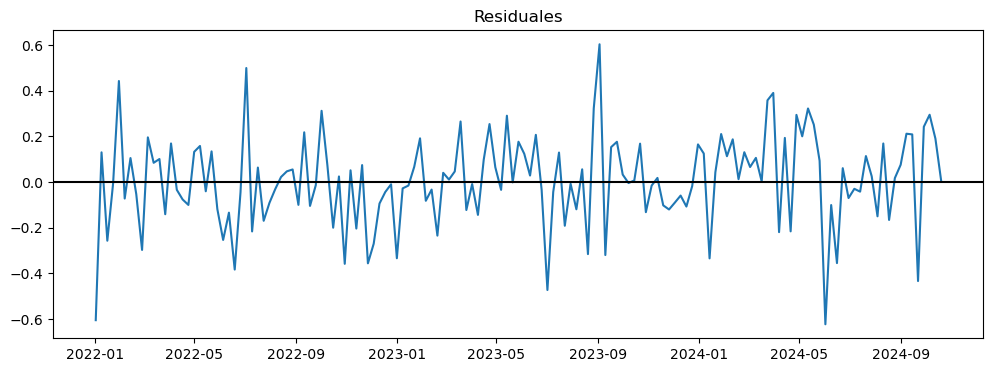

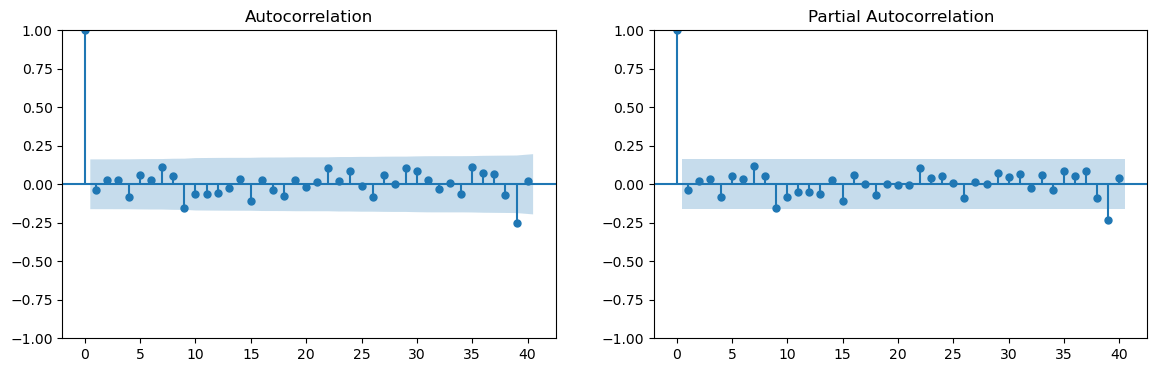

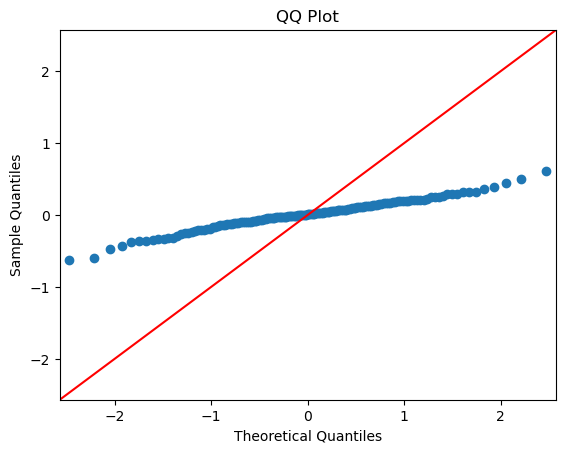

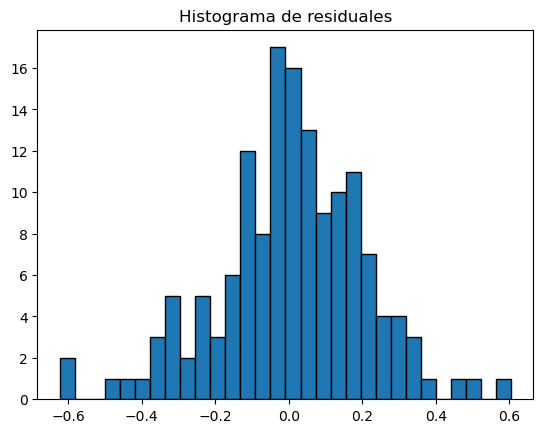

Desviación Estándar de Y_1: 0.399573182459628
Tu RMSE: 0.32391259348834933
¡El modelo FUNCIONA! Es predictivo.


In [38]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

std_dev = df_Y_semanal['Y_1'].std()
print(f"Desviación Estándar de Y_1: {std_dev}")
print(f"Tu RMSE: {best['RMSE']}")

if best['RMSE'] < std_dev:
    print("¡El modelo FUNCIONA! Es predictivo.")
else:
    print("Cuidado: El modelo no es mejor que el promedio.")

## PM10

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: -121.66733417307142
MAE: 20.057518159191893
RMSE: 29.120901254770118
MAPE: 35.9561242232657
R2: -0.1836472459116949
LjungBox_p: 0.27884141545090607
JarqueBera_p: 0.0
best_order: (2, 1, 3)
  Variable      Coef  AbsImpact        Pvalue
0     TOUT  0.113038   0.113038  1.155137e-08
3      PRS -0.091830   0.091830  1.828431e-17
1       RH -0.066411   0.066411  3.043211e-09
2       SR -0.013740   0.013740  2.802958e-01
                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1021
Model:               SARIMAX(2, 1, 3)   Log Likelihood                  70.834
Date:                Fri, 05 Dec 2025   AIC                           -121.667
Time:                        13:18:18   BIC                            -72.431
Sample:                    01-01-2022   HQIC                          -102.969
                         - 10-17-2024                                  

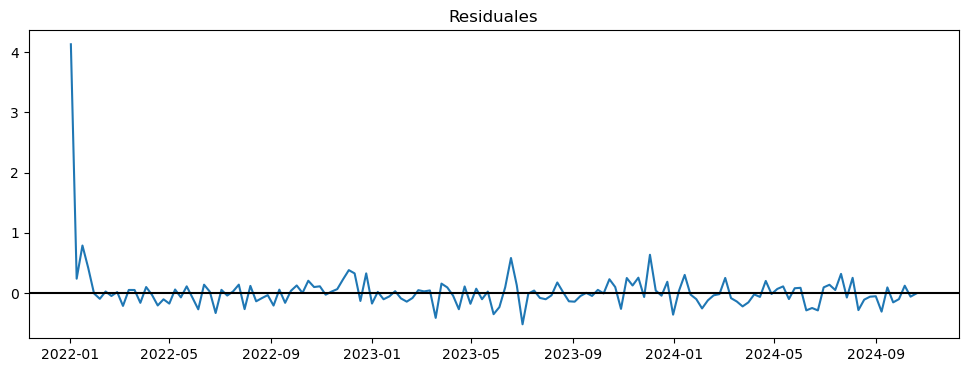

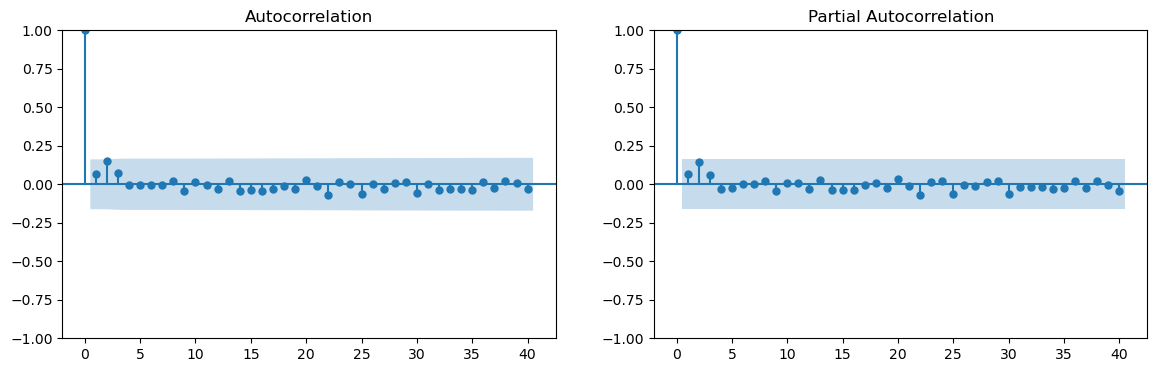

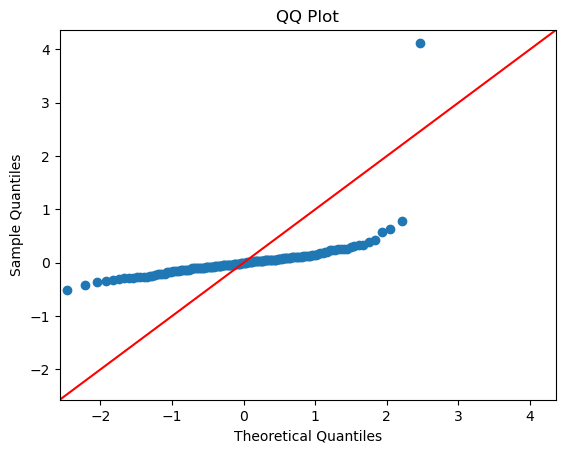

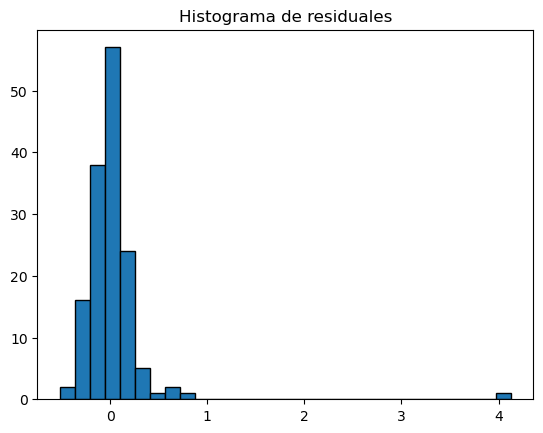

In [62]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM10", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

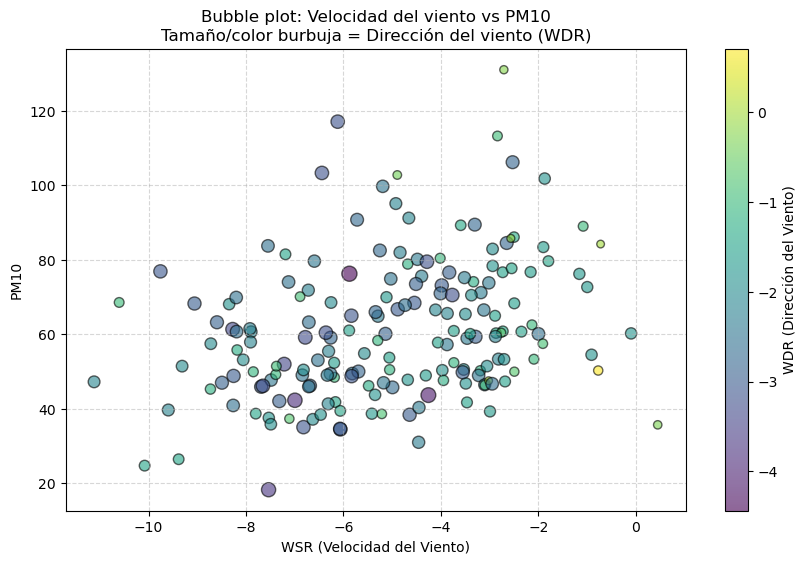

In [63]:
import matplotlib.pyplot as plt

# Bubble plot: WSR (Wind Speed) vs PM10 with bubble size=WDR (Wind Direction)
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df_Y_semanal["WSR"], 
    df_Y_semanal["PM10"], 
    s=np.abs(df_Y_semanal["WDR"])*20+30,  # Bubble size, scale for visibility
    c=df_Y_semanal["WDR"], 
    cmap="viridis", 
    alpha=0.6,
    edgecolor="k"
)
plt.xlabel("WSR (Velocidad del Viento)")
plt.ylabel("PM10")
plt.title("Bubble plot: Velocidad del viento vs PM10\nTamaño/color burbuja = Dirección del viento (WDR)")
cbar = plt.colorbar(scatter, label="WDR (Dirección del Viento)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## PM 2.5

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 7094.44937795742
MAE: 13.091075925376021
RMSE: 16.625592465005788
MAPE: 53.026116049729545
R2: -1.0955762979354193
LjungBox_p: 0.9040431573474316
JarqueBera_p: 3.610378459822244e-290
best_order: (4, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
0     TOUT  3.932284   3.932284  3.681981e-07
1       RH  3.714252   3.714252  6.539866e-19
3      PRS -2.888609   2.888609  1.896506e-13
2       SR  1.183892   1.183892  1.847406e-02
                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1021
Model:               SARIMAX(4, 1, 5)   Log Likelihood               -3533.225
Date:                Fri, 05 Dec 2025   AIC                           7094.449
Time:                        12:48:14   BIC                           7163.353
Sample:                    01-01-2022   HQIC                          7120.620
                         - 10-17-2024                 

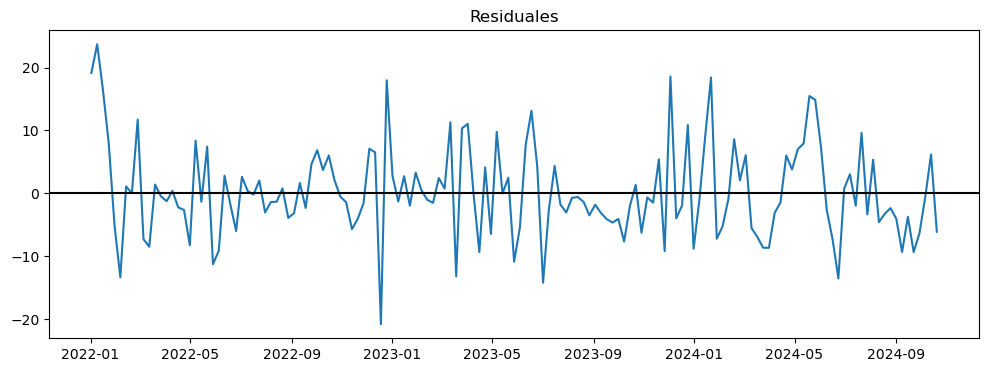

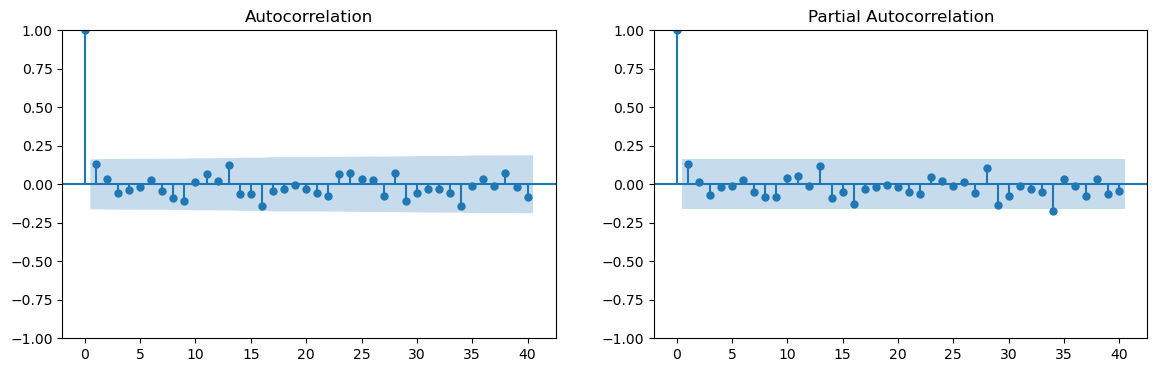

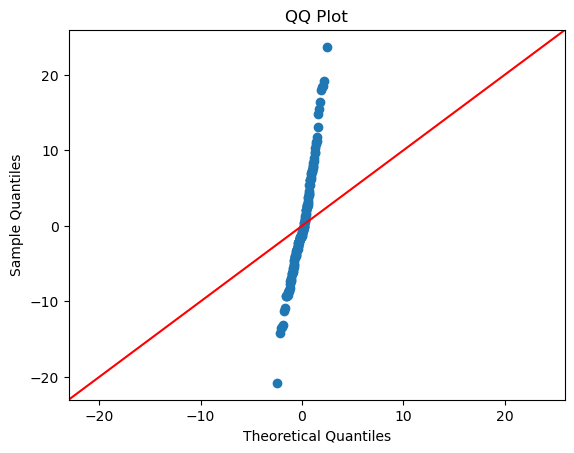

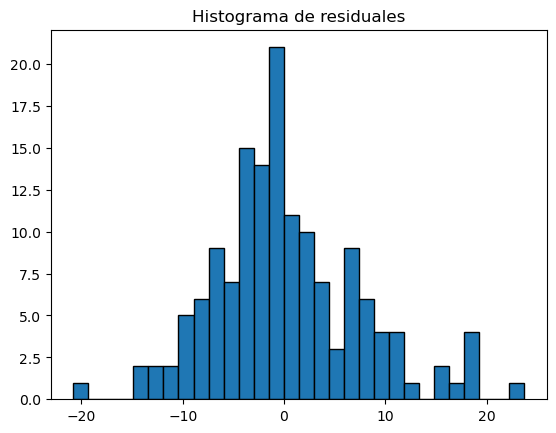

In [40]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM2.5", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)


## Y_3 (Nitrógenos)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 1017.5606844229835
MAE: 0.5093485256404503
RMSE: 0.6844777457340213
MAPE: 197.29649605031068
R2: -0.2667276665891023
LjungBox_p: 0.20253662107802073
JarqueBera_p: 0.0
best_order: (3, 0, 5)
  Variable      Coef  AbsImpact        Pvalue
3      PRS -0.188951   0.188951  1.694194e-22
0     TOUT  0.008608   0.008608  8.193629e-01
2       SR -0.004301   0.004301  8.677013e-01
1       RH -0.002334   0.002334  9.054040e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_3   No. Observations:                 1021
Model:               SARIMAX(3, 0, 5)   Log Likelihood                -495.780
Date:                Fri, 05 Dec 2025   AIC                           1017.561
Time:                        12:48:49   BIC                           1081.555
Sample:                    01-01-2022   HQIC                          1041.865
                         - 10-17-2024                                 

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


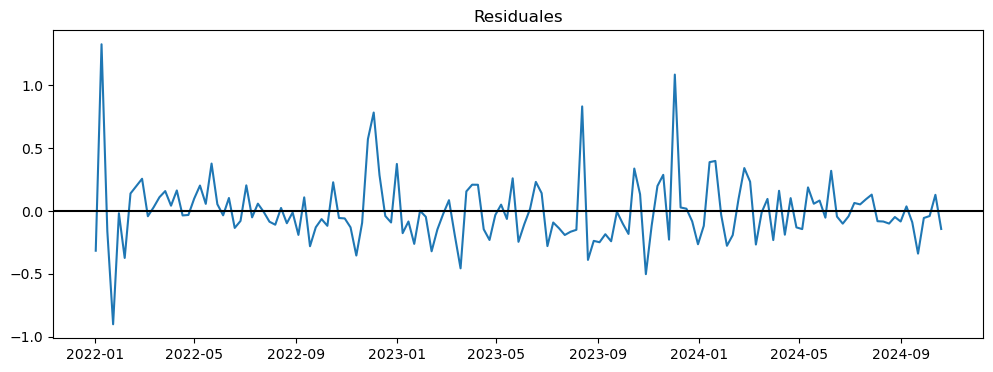

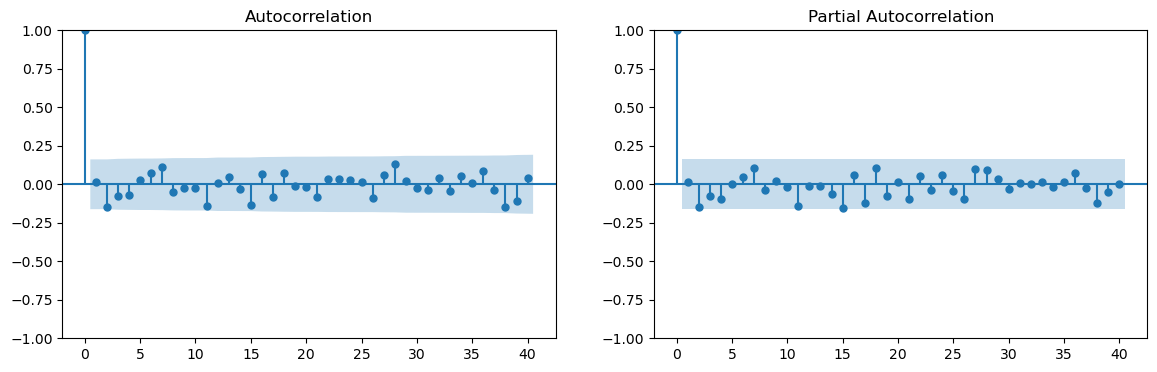

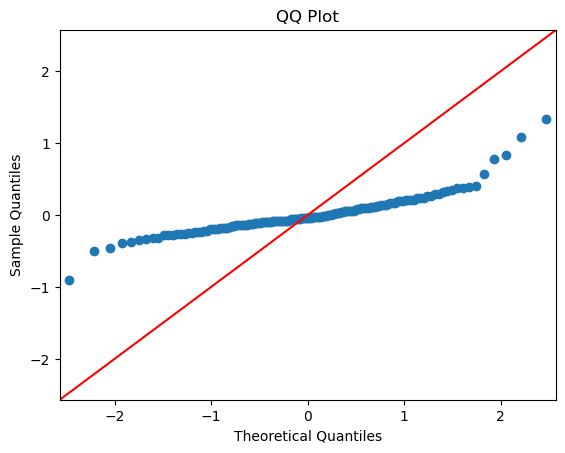

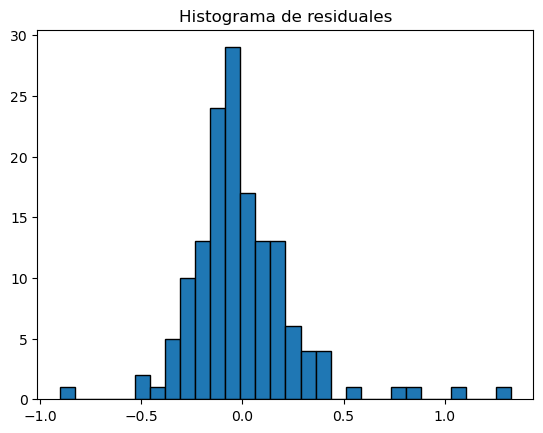

In [41]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_3", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)


## Y_4 (SO2)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: -947.9047879070124
MAE: 1.5026712252176377
RMSE: 2.1615926216317485
MAPE: 33.10144864590323
R2: -0.04107272333219436
LjungBox_p: 0.00015990923847137726
JarqueBera_p: 0.0
best_order: (5, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
1       RH -0.054686   0.054686  1.113010e-11
0     TOUT  0.018294   0.018294  1.979428e-01
3      PRS -0.010357   0.010357  2.257004e-01
2       SR  0.010222   0.010222  2.728891e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_4   No. Observations:                 1021
Model:               SARIMAX(5, 1, 5)   Log Likelihood                 488.952
Date:                Fri, 05 Dec 2025   AIC                           -947.905
Time:                        12:49:26   BIC                           -874.080
Sample:                    01-01-2022   HQIC                          -919.865
                         - 10-17-2024                              

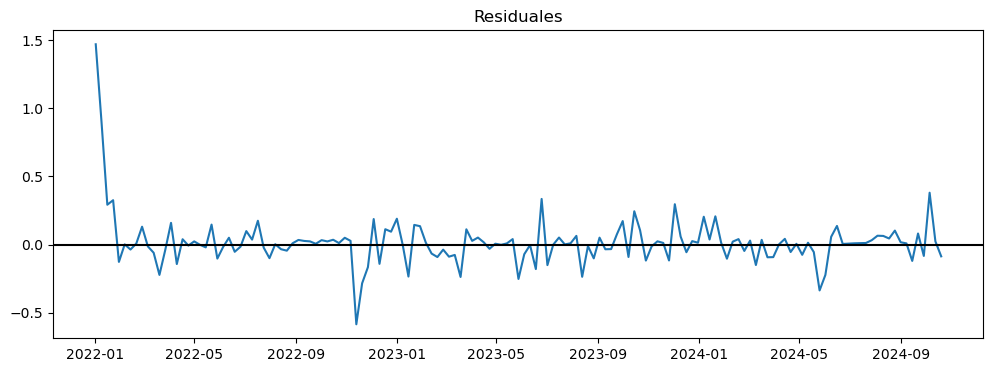

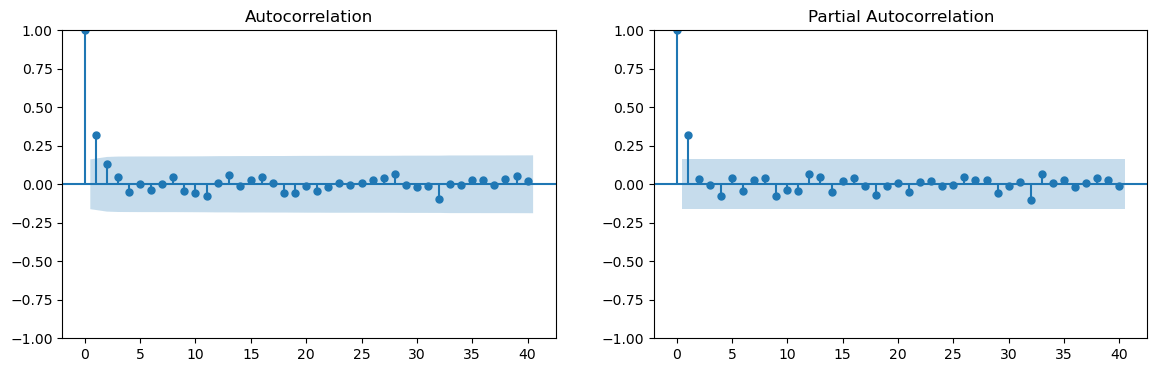

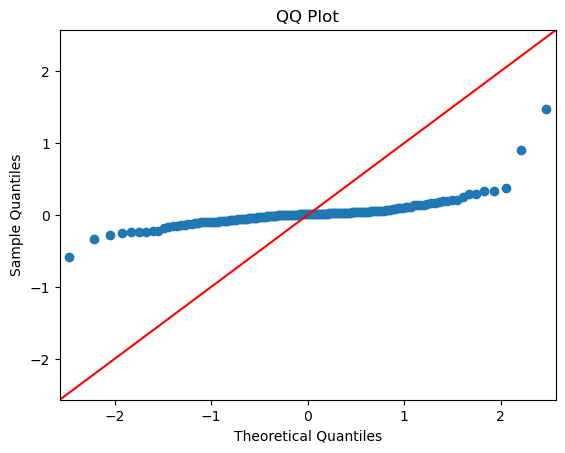

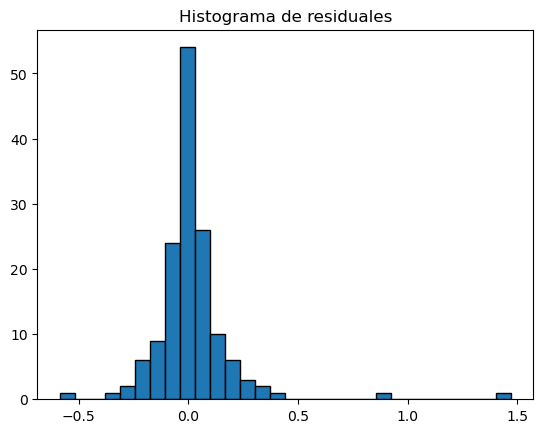

In [42]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_4", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

# SUROESTE 2

## data

In [43]:
SUROESTE2 = pd.read_csv("df_SUROESTE2_22_25.csv").drop(columns=["CO"])
SUROESTE2["PM10_std"] = (SUROESTE2["PM10"] - SUROESTE2["PM10"].mean()) / SUROESTE2["PM10"].std()
SUROESTE2["PM2.5_std"] = (SUROESTE2["PM2.5"] - SUROESTE2["PM2.5"].mean()) / SUROESTE2["PM2.5"].std()
SUROESTE2["NO_std"] = (SUROESTE2["NO"] - SUROESTE2["NO"].mean()) / SUROESTE2["NO"].std()
SUROESTE2["NO2_std"] = (SUROESTE2["NO2"] - SUROESTE2["NO2"].mean()) / SUROESTE2["NO2"].std()
SUROESTE2["SO2_std"] = (SUROESTE2["SO2"] - SUROESTE2["SO2"].mean()) / SUROESTE2["SO2"].std()
SUROESTE2["O3_std"] = (SUROESTE2["O3"] - SUROESTE2["O3"].mean()) / SUROESTE2["O3"].std()  # Agrega estandarización de O3

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
SUROESTE2["Y_1"] = SUROESTE2["O3_std"]
SUROESTE2["PM10"] = SUROESTE2["PM10"]
SUROESTE2["PM2.5"] = SUROESTE2["PM2.5"]
SUROESTE2["Y_3"] = SUROESTE2[["NO_std", "NO2_std"]].mean(axis=1)
SUROESTE2["Y_4"] = SUROESTE2["SO2"] 
# Incluye la columna "date" en el DataFrame resultado
SUROESTE2_Y = SUROESTE2[["date", "Y_1", "PM10", "PM2.5", "Y_3", "Y_4","TOUT", "RH", "SR", "PRS", "WSR", "WDR"]]


# --- Diario: ozono ('Y_1') con máximo, el resto con promedio ---
df_SUROESTE2_diario = SUROESTE2_Y.copy()
df_SUROESTE2_diario['date'] = pd.to_datetime(df_SUROESTE2_diario['date'])
df_SUROESTE2_diario = df_SUROESTE2_diario.set_index('date')
df_Y_diario = df_SUROESTE2_diario.resample("D").mean()

# --- Semanal: ozono ('Y_1') con máximo semanal, resto promedio ---
df_SUROESTE2_semanal = SUROESTE2_Y.copy()
df_SUROESTE2_semanal['date'] = pd.to_datetime(df_SUROESTE2_semanal['date'])
df_SUROESTE2_semanal = df_SUROESTE2_semanal.set_index('date')
df_Y_semanal = df_SUROESTE2_semanal.resample("W").mean()
df_Y_semanal.describe().T


,count,mean,std,min,25%,50%,75%,max
Y_1,184.0,-0.001820,0.442678,-0.974319,-0.273415,-0.039743,0.246792,1.268138
PM10,184.0,64.688000,39.213533,25.791667,48.313244,59.490744,72.407738,521.679345
PM2.5,184.0,18.026361,5.419464,7.500000,14.020833,17.162202,21.473244,41.181548
Y_3,184.0,-0.004329,0.437963,-0.643342,-0.347642,-0.129857,0.270746,1.509425
Y_4,184.0,4.475510,1.222788,1.720833,3.580134,4.304167,5.277530,8.610714
TOUT,184.0,22.845580,5.805539,7.508631,18.809122,23.884911,27.800937,33.241845
RH,184.0,53.462770,11.704201,17.315476,46.557314,53.616071,62.095238,85.422619
SR,184.0,0.166014,0.054087,0.047024,0.121074,0.167738,0.210833,0.269048
PRS,184.0,713.831819,1.019619,711.463095,713.128274,713.768155,714.458631,716.541071
WSR,184.0,-2.830623,5.765522,-15.280595,-7.596042,-3.047411,3.204613,8.170301


## Y_1 (Ozono)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 357.8721578308123
MAE: 0.33414656384616415
RMSE: 0.4039899297454513
MAPE: 153.56073835932912
R2: 0.4827950193035705
LjungBox_p: 0.27658942367361683
JarqueBera_p: 1.677051495827767e-32
best_order: (3, 0, 5)
  Variable      Coef  AbsImpact        Pvalue
1       RH -0.198518   0.198518  1.607702e-33
2       SR  0.103465   0.103465  4.692034e-20
0     TOUT  0.059923   0.059923  8.748328e-02
3      PRS  0.051499   0.051499  6.039319e-03
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                 1021
Model:               SARIMAX(3, 0, 5)   Log Likelihood                -165.936
Date:                Fri, 05 Dec 2025   AIC                            357.872
Time:                        12:50:15   BIC                            421.867
Sample:                    01-01-2022   HQIC                           382.177
                         - 10-17-2024                

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


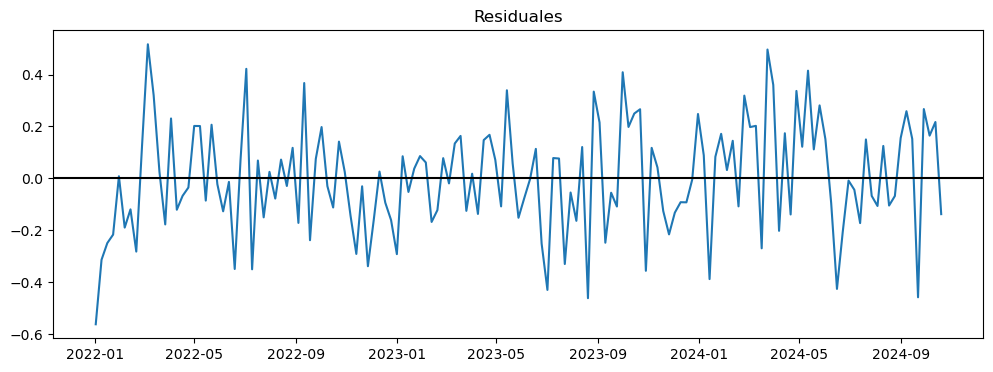

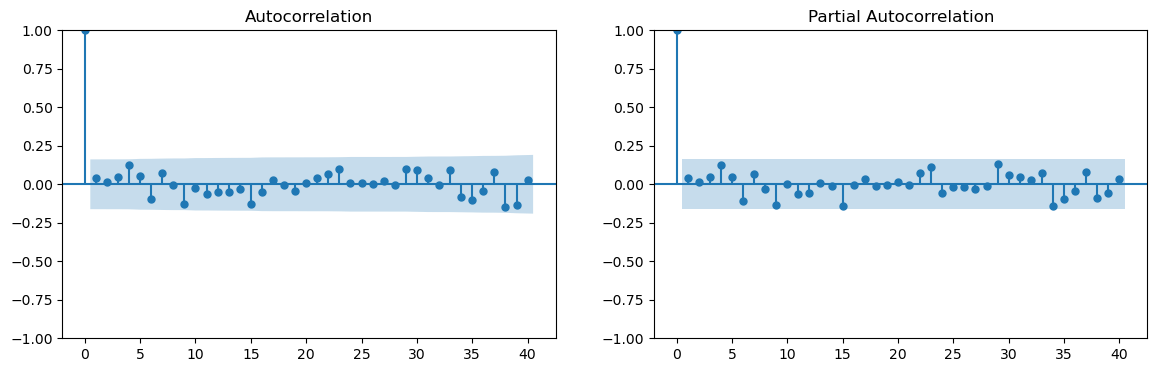

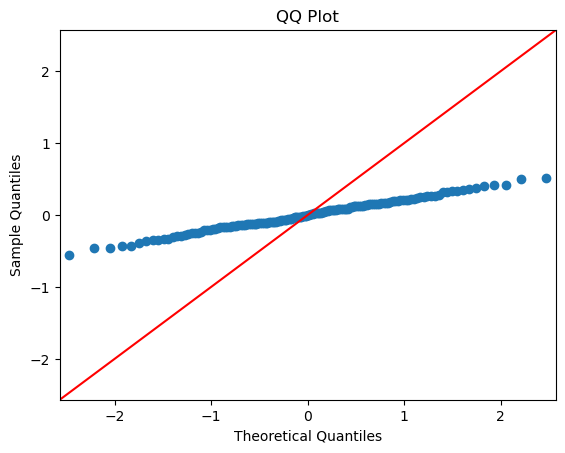

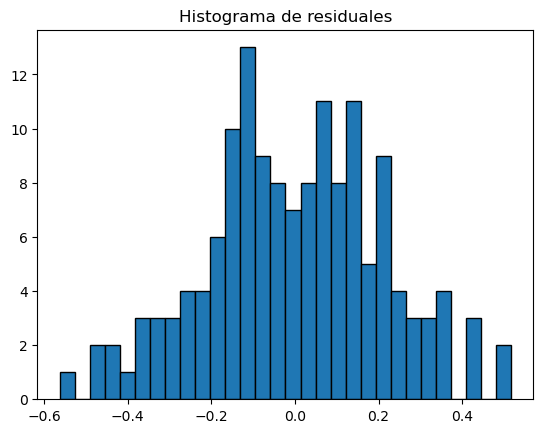

In [44]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## PM10

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 370.5990401795433
MAE: 21.70865731943825
RMSE: 32.65165545089833
MAPE: 34.93997229491607
R2: -0.4424930369188371
LjungBox_p: 0.11100772136371986
JarqueBera_p: 0.0
best_order: (5, 1, 3)
  Variable      Coef  AbsImpact        Pvalue
3      PRS -0.141939   0.141939  1.738480e-18
0     TOUT  0.104010   0.104010  4.464692e-04
1       RH -0.024008   0.024008  9.559545e-02
2       SR  0.019199   0.019199  2.407063e-01
                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1021
Model:               SARIMAX(5, 1, 3)   Log Likelihood                -172.300
Date:                Fri, 05 Dec 2025   AIC                            370.599
Time:                        12:50:52   BIC                            434.593
Sample:                    01-01-2022   HQIC                           394.904
                         - 10-17-2024                                     

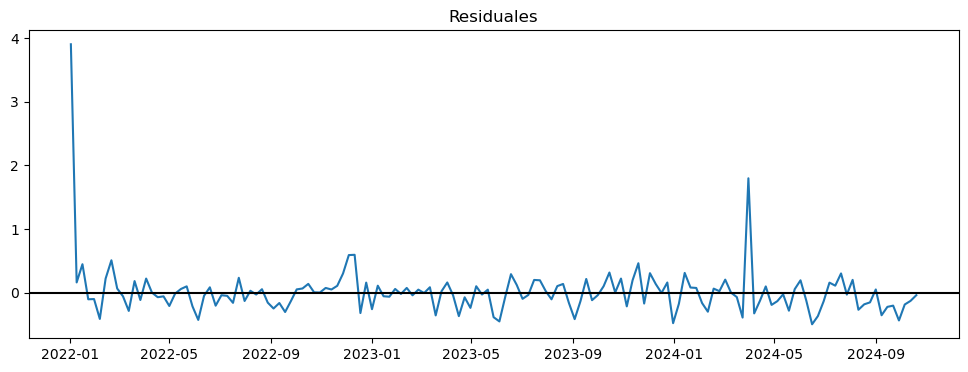

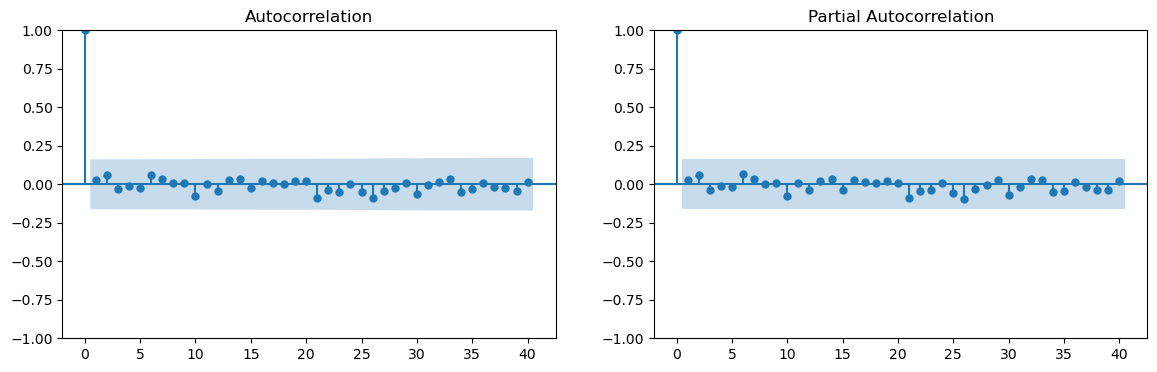

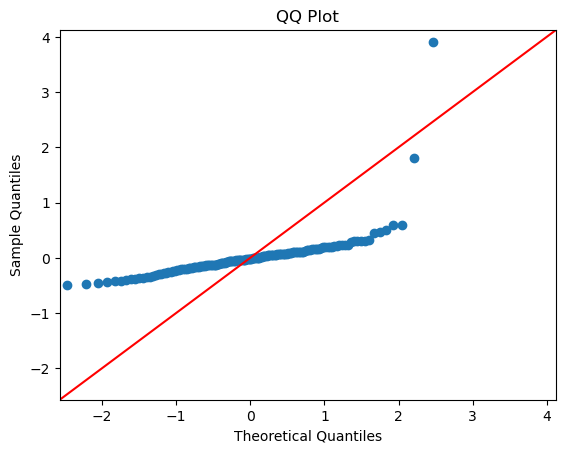

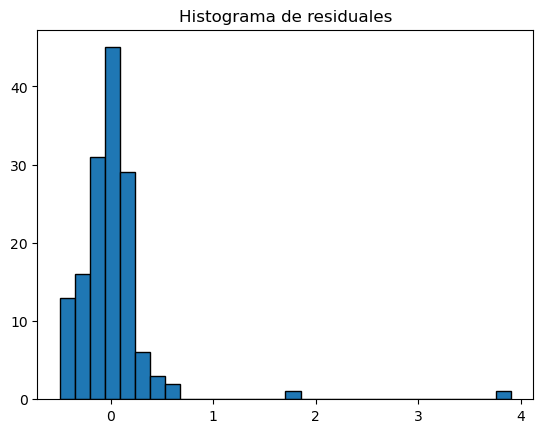

In [45]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM10", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## PM2.5

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 280.46943283085545
MAE: 8.014878421016302
RMSE: 10.385422762276422
MAPE: 38.419268602397715
R2: -0.8071609761384768
LjungBox_p: 0.9673651103799553
JarqueBera_p: 0.0
best_order: (1, 1, 3)
  Variable      Coef  AbsImpact        Pvalue
3      PRS -0.162793   0.162793  1.690498e-23
1       RH  0.137836   0.137836  8.318420e-21
0     TOUT  0.121167   0.121167  1.695699e-05
2       SR  0.048750   0.048750  1.020973e-03
                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1021
Model:               SARIMAX(1, 1, 3)   Log Likelihood                -131.235
Date:                Fri, 05 Dec 2025   AIC                            280.469
Time:                        12:51:29   BIC                            324.782
Sample:                    01-01-2022   HQIC                           297.298
                         - 10-17-2024                                   

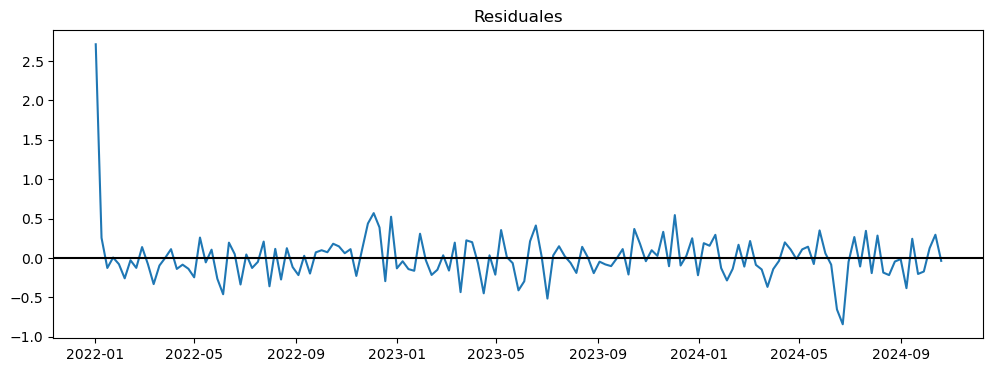

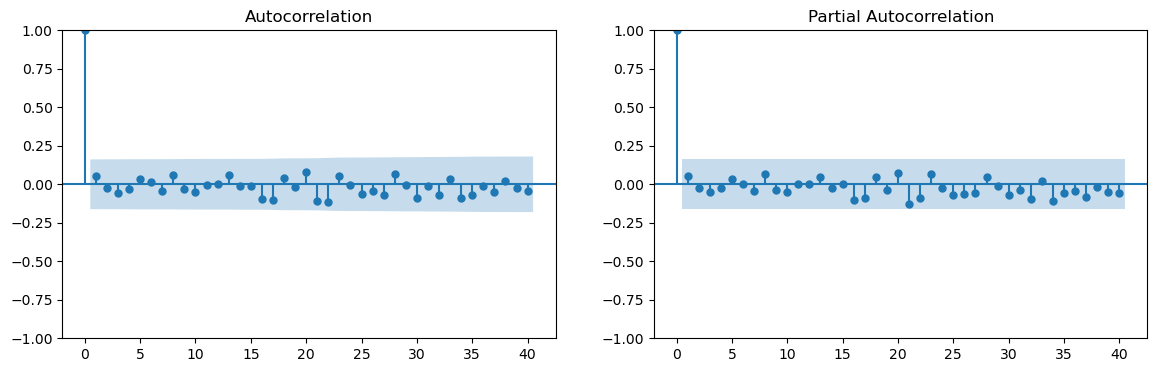

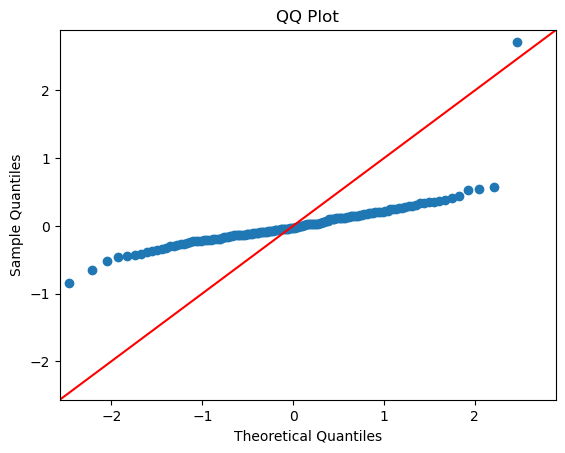

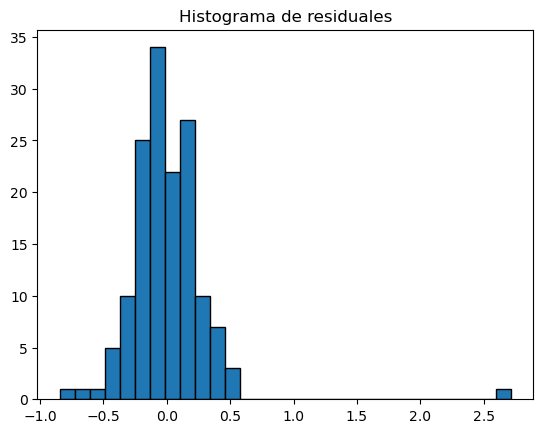

In [46]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM2.5", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## Y_3 (Nitrogeno)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 932.1803824076753
MAE: 0.4482630477410437
RMSE: 0.5983092128613201
MAPE: 230.90724479502046
R2: -0.06996853973924799
LjungBox_p: 0.2505008322543849
JarqueBera_p: 0.0
best_order: (3, 0, 5)
  Variable      Coef  AbsImpact        Pvalue
3      PRS -0.256128   0.256128  1.633731e-29
0     TOUT -0.129397   0.129397  9.018188e-04
2       SR -0.027894   0.027894  1.698684e-01
1       RH  0.015737   0.015737  4.325446e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_3   No. Observations:                 1021
Model:               SARIMAX(3, 0, 5)   Log Likelihood                -453.090
Date:                Fri, 05 Dec 2025   AIC                            932.180
Time:                        12:52:05   BIC                            996.175
Sample:                    01-01-2022   HQIC                           956.485
                         - 10-17-2024                                  

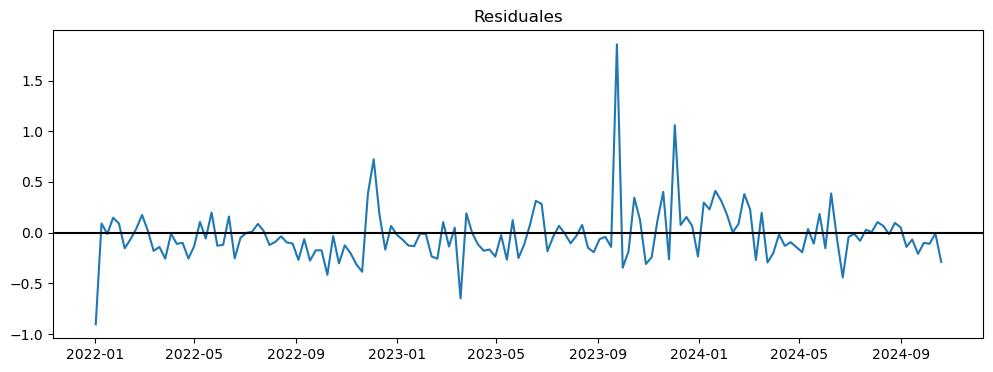

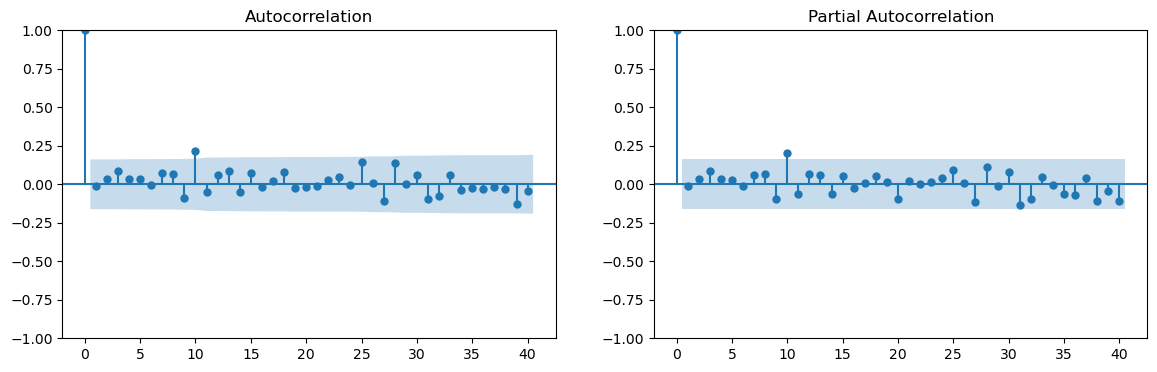

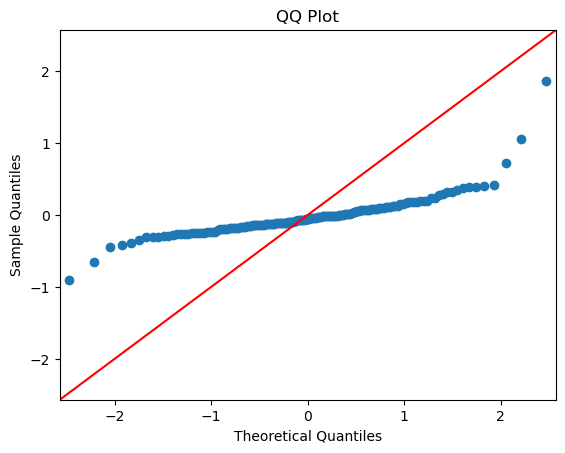

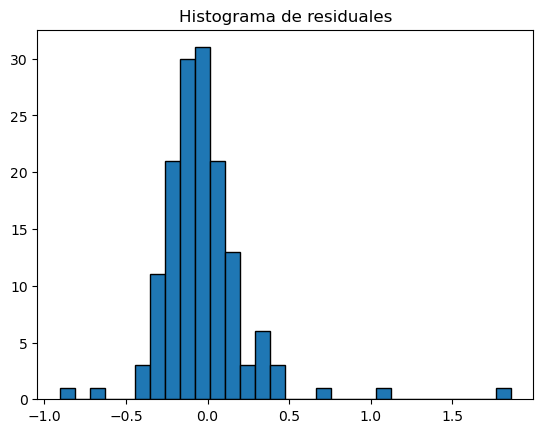

In [47]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_3", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## Y_4 (SO2)

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: -871.5329826390589
MAE: 1.5418284482968394
RMSE: 2.2709442206326504
MAPE: 25.489555203543713
R2: -0.4916963727608106
LjungBox_p: 0.17948020493594086
JarqueBera_p: 0.0
best_order: (4, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
1       RH -0.058057   0.058057  1.095530e-11
3      PRS -0.041554   0.041554  5.020882e-06
2       SR  0.013753   0.013753  1.796921e-01
0     TOUT  0.003124   0.003124  8.495719e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_4   No. Observations:                 1021
Model:               SARIMAX(4, 1, 5)   Log Likelihood                 449.766
Date:                Fri, 05 Dec 2025   AIC                           -871.533
Time:                        12:52:43   BIC                           -802.630
Sample:                    01-01-2022   HQIC                          -845.363
                         - 10-17-2024                                 

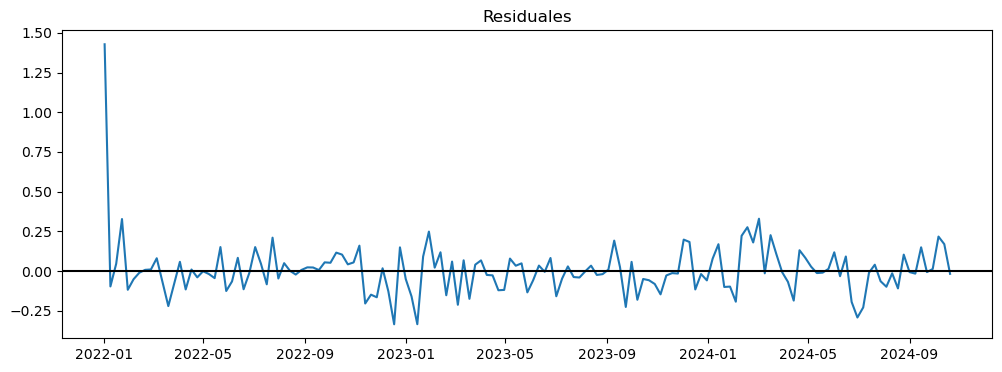

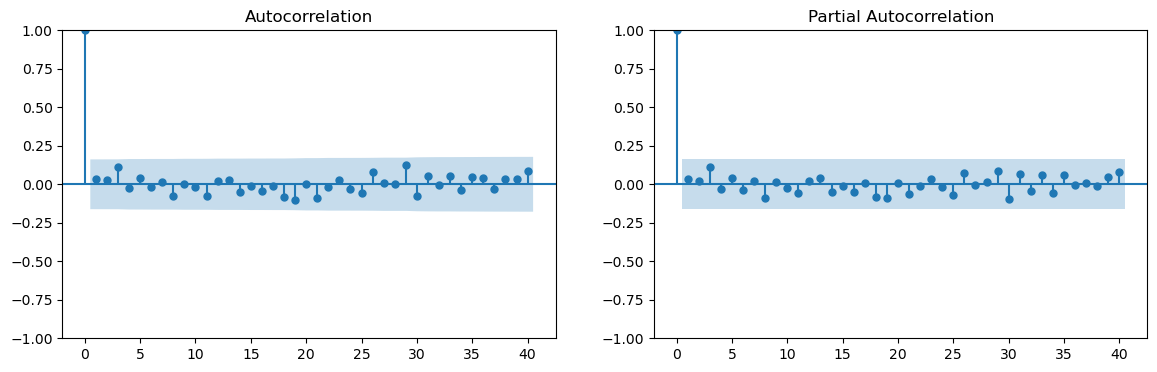

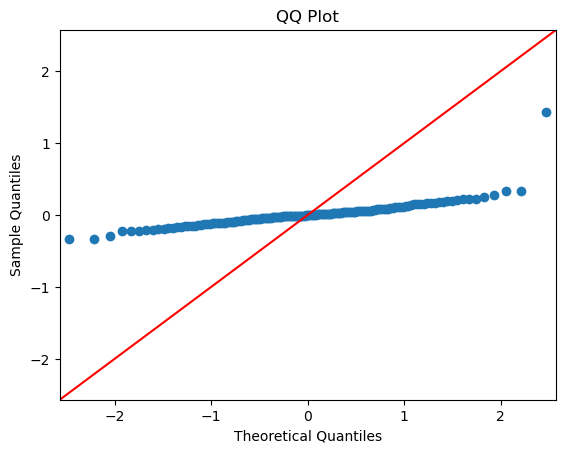

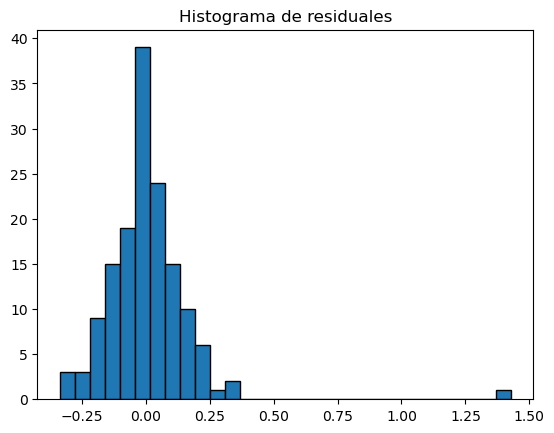

In [48]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_4", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

# NORTE 2

## DATA

In [64]:
NORTE2 = pd.read_csv("df_NORTE2_22_25.csv").drop(columns=["CO"])
NORTE2["PM10_std"] = (NORTE2["PM10"] - NORTE2["PM10"].mean()) / NORTE2["PM10"].std()
NORTE2["PM2.5_std"] = (NORTE2["PM2.5"] - NORTE2["PM2.5"].mean()) / NORTE2["PM2.5"].std()
NORTE2["NO_std"] = (NORTE2["NO"] - NORTE2["NO"].mean()) / NORTE2["NO"].std()
NORTE2["NO2_std"] = (NORTE2["NO2"] - NORTE2["NO2"].mean()) / NORTE2["NO2"].std()
NORTE2["SO2_std"] = (NORTE2["SO2"] - NORTE2["SO2"].mean()) / NORTE2["SO2"].std()
NORTE2["O3_std"] = (NORTE2["O3"] - NORTE2["O3"].mean()) / NORTE2["O3"].std()  # Agrega estandarización de O3

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
NORTE2["Y_1"] = NORTE2["O3_std"]
NORTE2["PM10"] = NORTE2["PM10"]
NORTE2["PM2.5"] = NORTE2["PM2.5"]
NORTE2["Y_3"] = NORTE2[["NO_std", "NO2_std"]].mean(axis=1)
NORTE2["Y_4"] = NORTE2["SO2"] 
# Incluye la columna "date" en el DataFrame resultado
NORTE2_Y = NORTE2[["date", "Y_1", "PM10", "PM2.5", "Y_3", "Y_4","TOUT", "RH", "SR", "PRS", "WSR", "WDR"]]


# --- Diario: ozono ('Y_1') con máximo, el resto con promedio ---
df_NORTE2_diario = NORTE2_Y.copy()
df_NORTE2_diario['date'] = pd.to_datetime(df_NORTE2_diario['date'])
df_NORTE2_diario = df_NORTE2_diario.set_index('date')
df_Y_diario = df_NORTE2_diario.resample("D").mean()

# --- Semanal: ozono ('Y_1') con máximo semanal, resto promedio ---
df_NORTE2_semanal = NORTE2_Y.copy()
df_NORTE2_semanal['date'] = pd.to_datetime(df_NORTE2_semanal['date'])
df_NORTE2_semanal = df_NORTE2_semanal.set_index('date')
df_Y_semanal = df_NORTE2_semanal.resample("W").mean()
df_Y_semanal.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,184.0,-0.002786,0.391885,-1.051005,-0.235762,-0.050864,0.232745,1.107350
PM10,184.0,66.575795,21.683259,20.291667,50.209077,64.273810,80.118304,155.553571
PM2.5,184.0,20.184154,6.177195,7.500000,16.158482,19.242560,22.796131,46.333333
Y_3,184.0,-0.004226,0.522349,-0.816333,-0.446707,-0.099710,0.380259,1.359988
Y_4,184.0,4.638304,1.358392,2.383333,3.667560,4.253452,5.709896,8.847917
TOUT,184.0,23.817043,5.766273,8.486607,19.889122,24.984613,28.650446,33.779643
RH,184.0,54.526519,11.086294,21.386905,47.601190,55.065476,62.519345,85.363095
SR,184.0,0.122974,0.040707,0.027798,0.089762,0.126429,0.157292,0.203571
PRS,184.0,712.717965,2.637694,706.847619,710.924851,712.562202,714.355804,720.259524
WSR,184.0,-4.722065,2.462139,-11.406488,-6.481205,-4.648988,-2.812366,3.065417


## Y_1

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 288.5605175195944
MAE: 0.36811399791401467
RMSE: 0.44492090592463207
MAPE: 117.67669127301106
R2: 0.31709318893617344
LjungBox_p: 0.3597597037023682
JarqueBera_p: 5.565940964273712e-17
best_order: (2, 0, 1)
  Variable      Coef  AbsImpact        Pvalue
2       SR  0.149814   0.149814  3.987190e-20
1       RH -0.115038   0.115038  2.139496e-14
0     TOUT -0.051106   0.051106  1.059155e-01
3      PRS  0.011887   0.011887  4.847494e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                 1021
Model:               SARIMAX(2, 0, 1)   Log Likelihood                -136.280
Date:                Fri, 05 Dec 2025   AIC                            288.561
Time:                        12:53:18   BIC                            327.973
Sample:                    01-01-2022   HQIC                           303.526
                         - 10-17-2024               

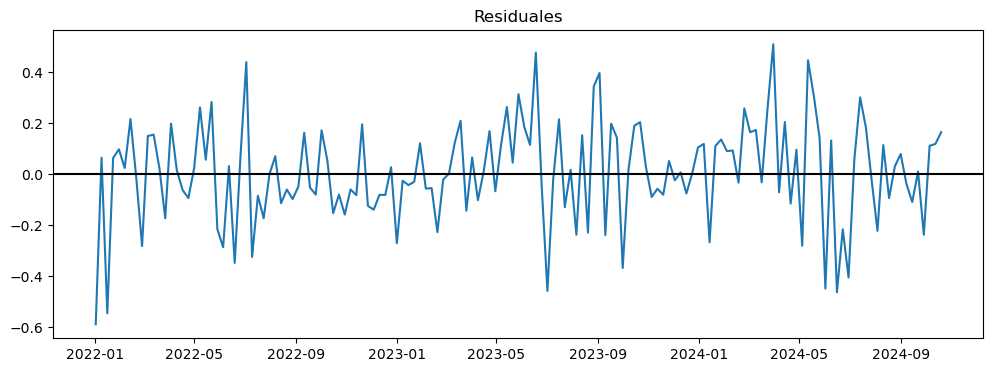

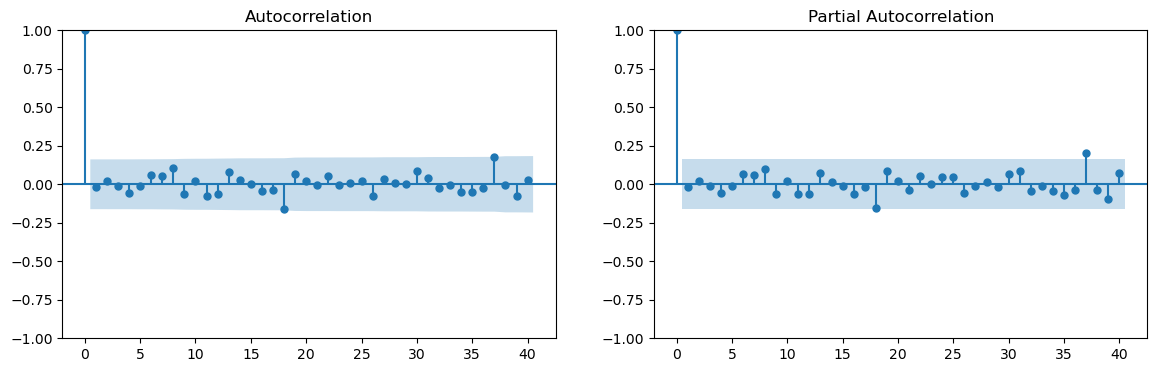

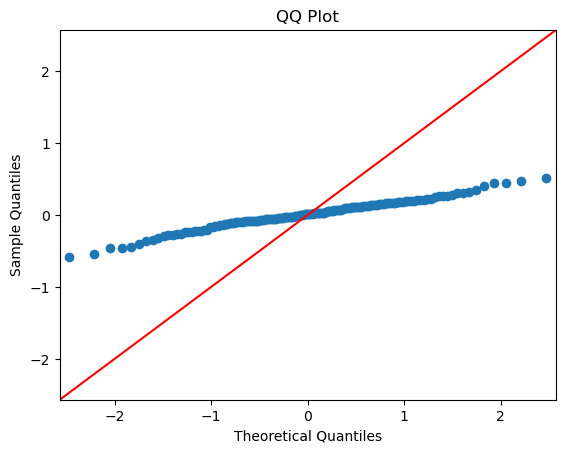

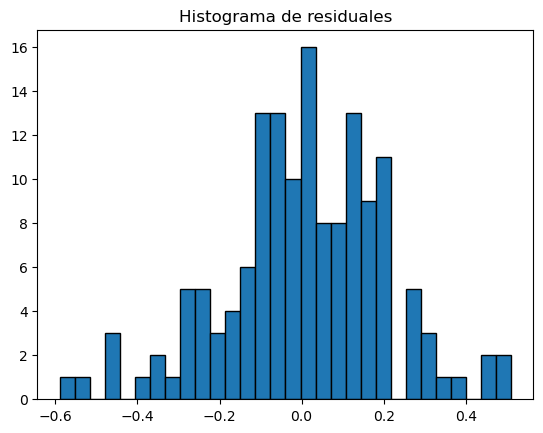

In [50]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## PM10

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 305.3346807951324
MAE: 28.123390432648183
RMSE: 35.866331010819565
MAPE: 46.001134998572084
R2: -0.20066590315903388
LjungBox_p: 0.004031109821456858
JarqueBera_p: 0.0
best_order: (2, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
0     TOUT  0.207214   0.207214  1.781240e-16
1       RH -0.109824   0.109824  6.675710e-15
3      PRS -0.093610   0.093610  2.263177e-11
2       SR -0.005963   0.005963  7.479803e-01
                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                 1021
Model:               SARIMAX(2, 1, 5)   Log Likelihood                -140.667
Date:                Fri, 05 Dec 2025   AIC                            305.335
Time:                        13:19:51   BIC                            364.395
Sample:                    01-01-2022   HQIC                           327.766
                         - 10-17-2024                                

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


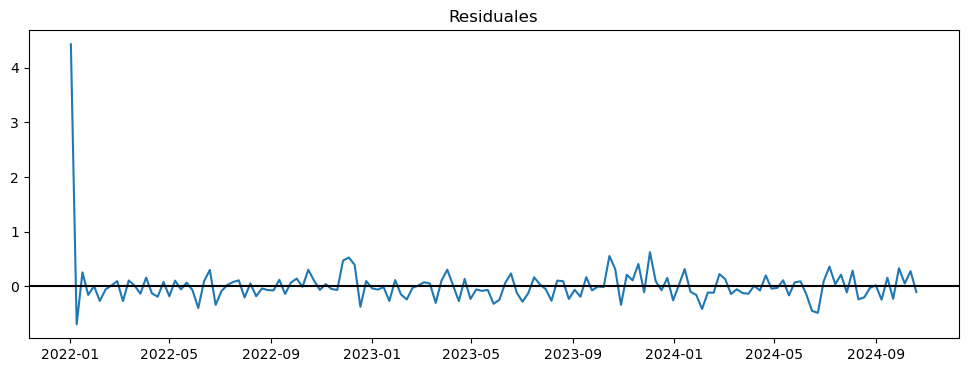

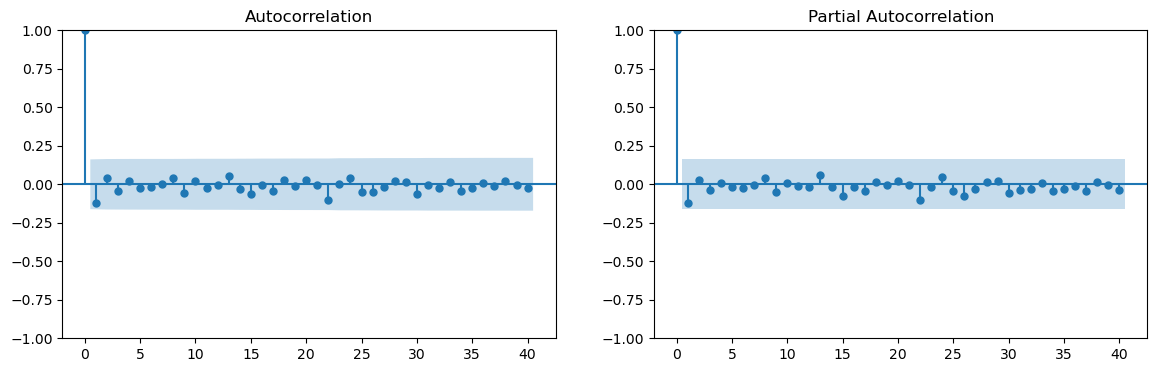

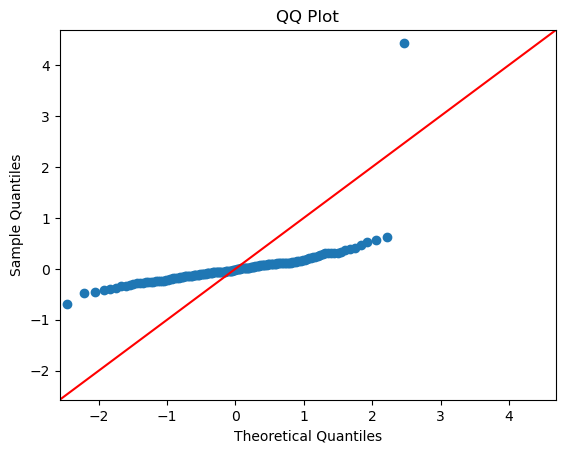

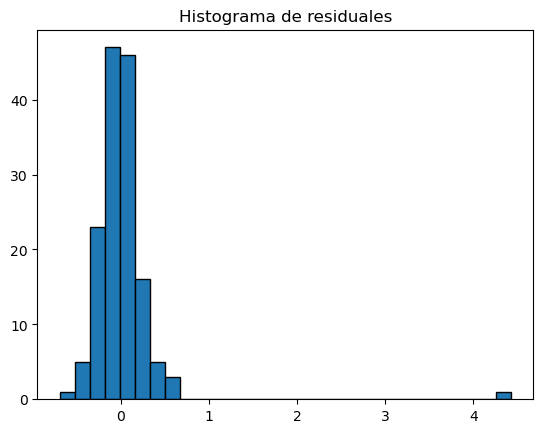

In [65]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM10", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

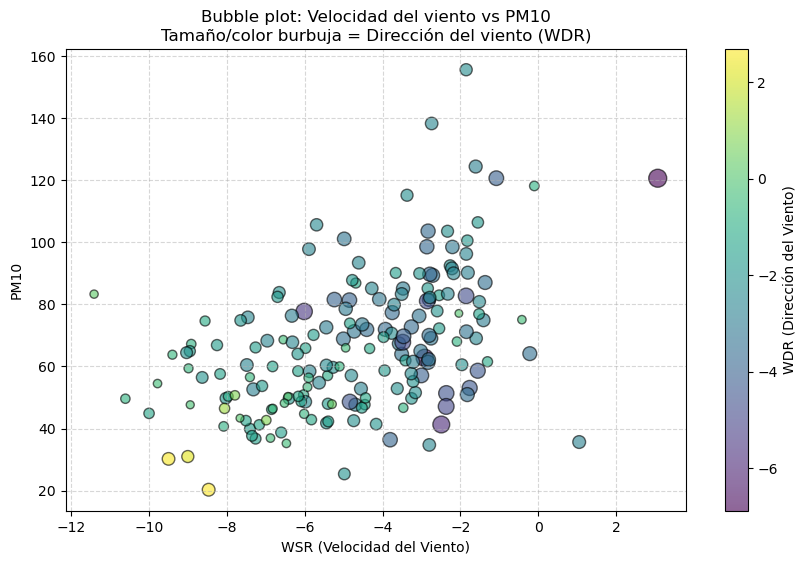

In [66]:
import matplotlib.pyplot as plt

# Bubble plot: WSR (Wind Speed) vs PM10 with bubble size=WDR (Wind Direction)
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    df_Y_semanal["WSR"], 
    df_Y_semanal["PM10"], 
    s=np.abs(df_Y_semanal["WDR"])*20+30,  # Bubble size, scale for visibility
    c=df_Y_semanal["WDR"], 
    cmap="viridis", 
    alpha=0.6,
    edgecolor="k"
)
plt.xlabel("WSR (Velocidad del Viento)")
plt.ylabel("PM10")
plt.title("Bubble plot: Velocidad del viento vs PM10\nTamaño/color burbuja = Dirección del viento (WDR)")
cbar = plt.colorbar(scatter, label="WDR (Dirección del Viento)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## PM2.5

In [52]:
#out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM2.5", y_transform=np.log1p, inverse_transform=np.expm1)
#
#
#for best in [out["best_daily"], out["best_weekly"]]:
#    print("Frecuencia seleccionada:", best["freq"])
#    print("AIC:", best["AIC"])
#    print("MAE:", best["MAE"])
#    print("RMSE:", best["RMSE"])
#    print("MAPE:", best["MAPE"])
#    print("R2:", best["R2"])
#    print("LjungBox_p:", best["LjungBox_p"])
#    print("JarqueBera_p:", best["JarqueBera_p"])
#    print("best_order:", best["best_order"])
#    print(best["coef_table"])
#    print(best["results"].summary())
#
#plot_diagnostics(best)

## Y_3

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 725.614370300593
MAE: 0.6717396276656267
RMSE: 0.8153749813701646
MAPE: 228.69345463614482
R2: -0.014812270203383493
LjungBox_p: 0.059293509322254745
JarqueBera_p: 4.002312697517123e-268
best_order: (3, 0, 5)
  Variable      Coef  AbsImpact        Pvalue
3      PRS -0.131764   0.131764  5.181183e-14
1       RH -0.091970   0.091970  2.251542e-08
0     TOUT  0.080228   0.080228  1.304666e-02
2       SR -0.069800   0.069800  2.051068e-03
                               SARIMAX Results                                
Dep. Variable:                    Y_3   No. Observations:                 1021
Model:               SARIMAX(3, 0, 5)   Log Likelihood                -349.807
Date:                Fri, 05 Dec 2025   AIC                            725.614
Time:                        12:53:56   BIC                            789.609
Sample:                    01-01-2022   HQIC                           749.919
                         - 10-17-2024             

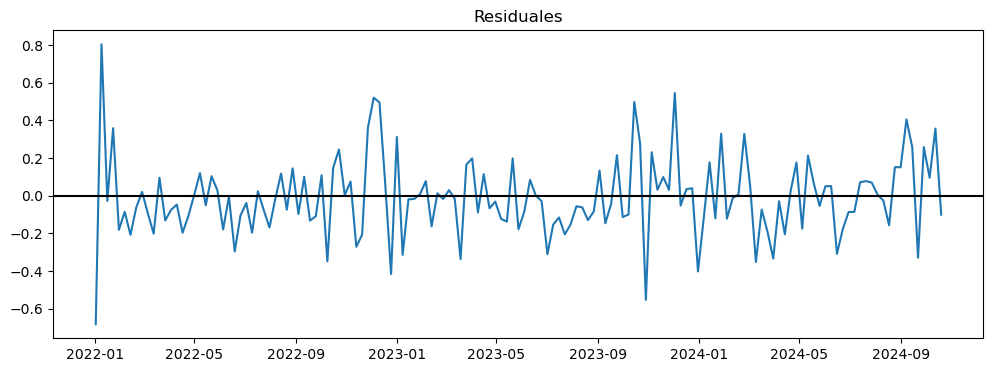

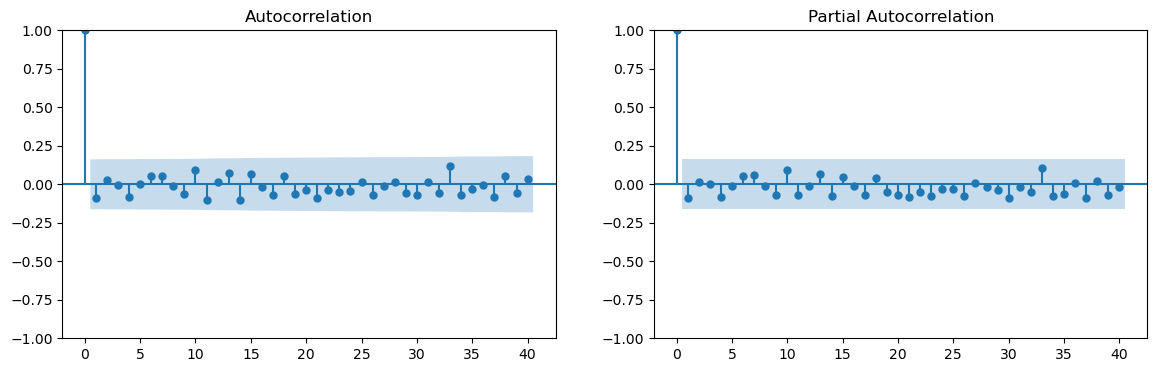

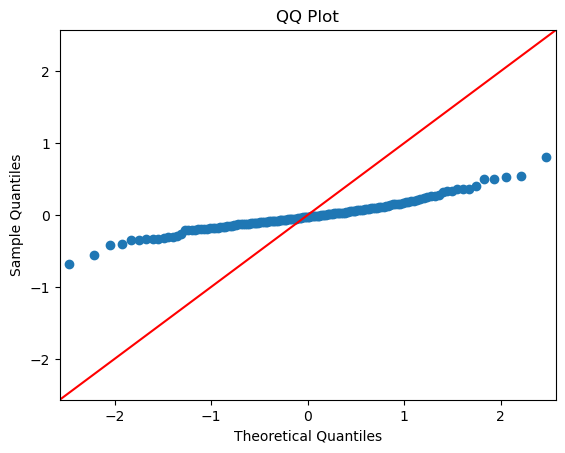

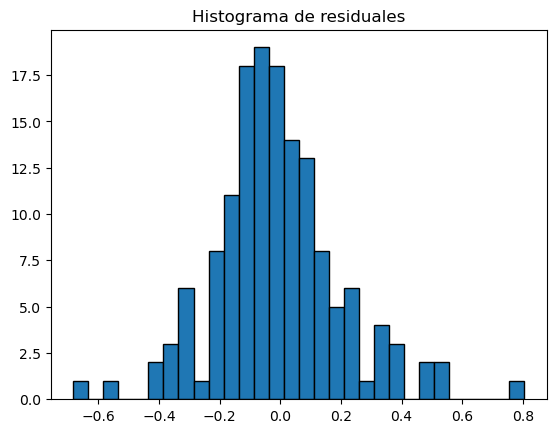

In [53]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_3", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## Y_4

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 2993.722274341589
MAE: 0.7598789393588927
RMSE: 0.927954316660551
MAPE: 20.11297896382434
R2: -0.5570249616617773
LjungBox_p: 0.2725960724589588
JarqueBera_p: 0.0
best_order: (4, 1, 4)
  Variable      Coef  AbsImpact        Pvalue
1       RH -0.340252   0.340252  2.357812e-09
0     TOUT  0.198533   0.198533  6.689722e-02
3      PRS -0.134035   0.134035  2.388712e-02
2       SR -0.018119   0.018119  8.156799e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_4   No. Observations:                 1021
Model:               SARIMAX(4, 1, 4)   Log Likelihood               -1483.861
Date:                Fri, 05 Dec 2025   AIC                           2993.722
Time:                        12:54:31   BIC                           3057.717
Sample:                    01-01-2022   HQIC                          3018.027
                         - 10-17-2024                                     

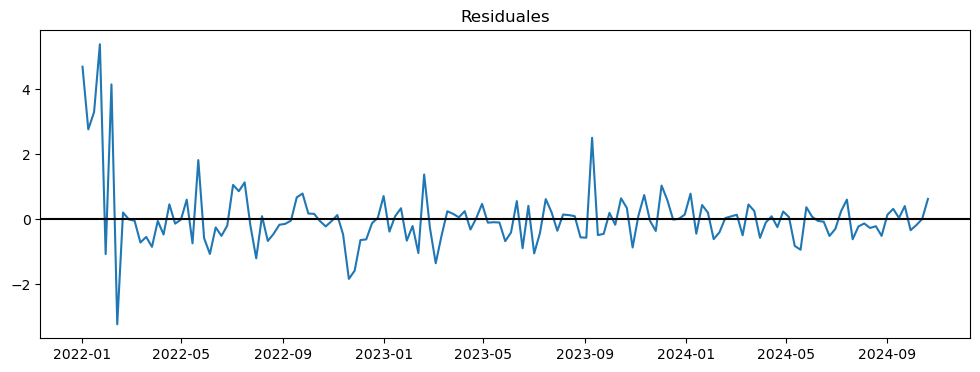

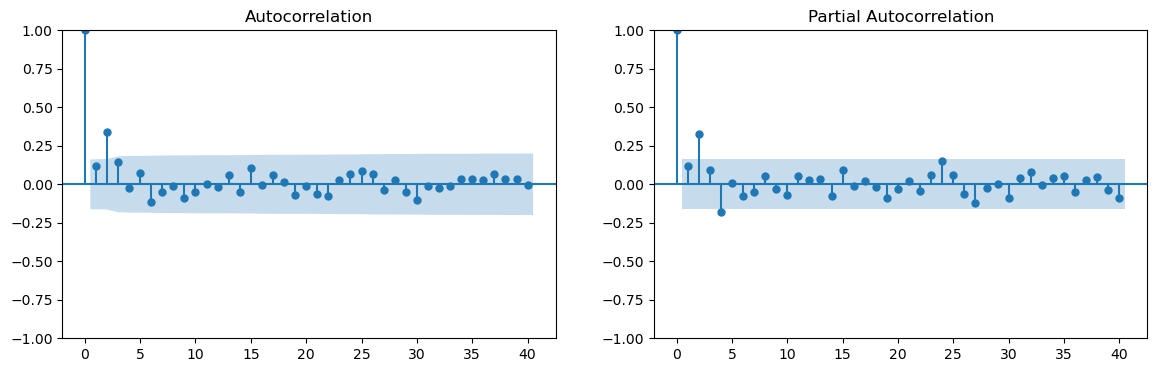

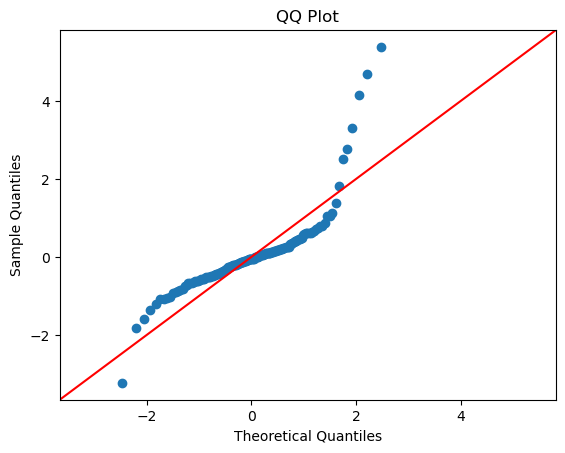

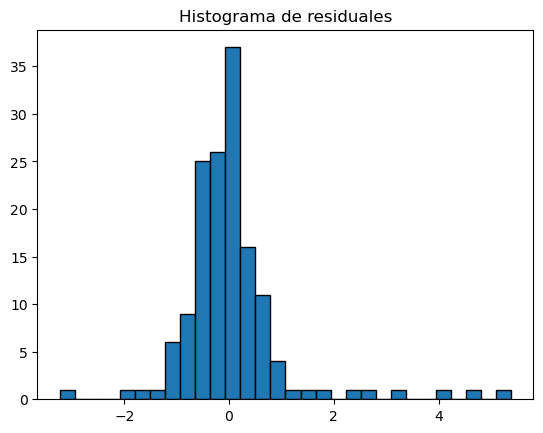

In [54]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_4", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

# SURESTE3

## DATA

In [55]:
SURESTE3 = pd.read_csv("df_SURESTE3_22_25.csv").drop(columns=["CO"])
SURESTE3["PM10_std"] = (SURESTE3["PM10"] - SURESTE3["PM10"].mean()) / SURESTE3["PM10"].std()
SURESTE3["PM2.5_std"] = (SURESTE3["PM2.5"] - SURESTE3["PM2.5"].mean()) / SURESTE3["PM2.5"].std()
SURESTE3["NO_std"] = (SURESTE3["NO"] - SURESTE3["NO"].mean()) / SURESTE3["NO"].std()
SURESTE3["NO2_std"] = (SURESTE3["NO2"] - SURESTE3["NO2"].mean()) / SURESTE3["NO2"].std()
SURESTE3["SO2_std"] = (SURESTE3["SO2"] - SURESTE3["SO2"].mean()) / SURESTE3["SO2"].std()
SURESTE3["O3_std"] = (SURESTE3["O3"] - SURESTE3["O3"].mean()) / SURESTE3["O3"].std()  # Agrega estandarización de O3

# Crear los grupos Y en 'centro', incluyendo la fecha de captura
SURESTE3["Y_1"] = SURESTE3["O3_std"]
SURESTE3["PM10"] = SURESTE3["PM10"]
SURESTE3["PM2.5"] = SURESTE3["PM2.5"]
SURESTE3["Y_3"] = SURESTE3[["NO_std", "NO2_std"]].mean(axis=1)
SURESTE3["Y_4"] = SURESTE3["SO2"] 
# Incluye la columna "date" en el DataFrame resultado
SURESTE3_Y = SURESTE3[["date", "Y_1", "PM10", "PM2.5", "Y_3", "Y_4","TOUT", "RH", "SR", "PRS", "WSR", "WDR"]]


# --- Diario: ozono ('Y_1') con máximo, el resto con promedio ---
df_SURESTE3_diario = SURESTE3_Y.copy()
df_SURESTE3_diario['date'] = pd.to_datetime(df_SURESTE3_diario['date'])
df_SURESTE3_diario = df_SURESTE3_diario.set_index('date')
df_Y_diario = df_SURESTE3_diario.resample("D").mean()

# --- Semanal: ozono ('Y_1') con máximo semanal, resto promedio ---
df_SURESTE3_semanal = SURESTE3_Y.copy()
df_SURESTE3_semanal['date'] = pd.to_datetime(df_SURESTE3_semanal['date'])
df_SURESTE3_semanal = df_SURESTE3_semanal.set_index('date')
df_Y_semanal = df_SURESTE3_semanal.resample("W").mean()
df_Y_semanal.describe().T

,count,mean,std,min,25%,50%,75%,max
Y_1,184.0,-0.003322,0.388488,-1.033372,-0.247699,-0.018803,0.162394,1.133903
PM10,184.0,68.307322,24.305910,21.750000,49.427083,63.849702,82.555804,163.095238
PM2.5,184.0,20.518373,9.492211,7.191667,13.431548,18.217262,25.084077,57.383929
Y_3,184.0,-0.001839,0.484383,-0.581269,-0.383248,-0.126715,0.253310,1.571474
Y_4,184.0,6.708993,3.511275,2.316667,4.376042,6.230625,7.926339,27.434524
TOUT,184.0,23.614979,5.842768,8.346131,19.416667,24.799494,28.301622,32.891369
RH,184.0,59.695420,10.768387,22.369048,52.102679,59.901786,67.638393,87.869048
SR,184.0,0.148021,0.051548,0.030417,0.106429,0.151905,0.188170,0.277083
PRS,184.0,728.342952,5.025411,720.214881,723.423661,729.235119,731.689583,741.079762
WSR,184.0,-2.940963,3.203337,-12.996964,-4.680818,-2.075446,-0.707217,6.387292


## Y_1

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 324.83136987678097
MAE: 0.3280294405522609
RMSE: 0.4222167070067843
MAPE: 233.06838530602045
R2: 0.35165581159658044
LjungBox_p: 0.8755212917814157
JarqueBera_p: 8.8216523910113e-31
best_order: (5, 0, 4)
  Variable      Coef  AbsImpact        Pvalue
1       RH -0.145964   0.145964  1.303050e-30
2       SR  0.098259   0.098259  6.129739e-11
0     TOUT -0.049288   0.049288  3.379245e-02
3      PRS -0.001638   0.001638  8.912057e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_1   No. Observations:                 1021
Model:               SARIMAX(5, 0, 4)   Log Likelihood                -148.416
Date:                Fri, 05 Dec 2025   AIC                            324.831
Time:                        12:55:32   BIC                            393.762
Sample:                    01-01-2022   HQIC                           351.010
                         - 10-17-2024                  

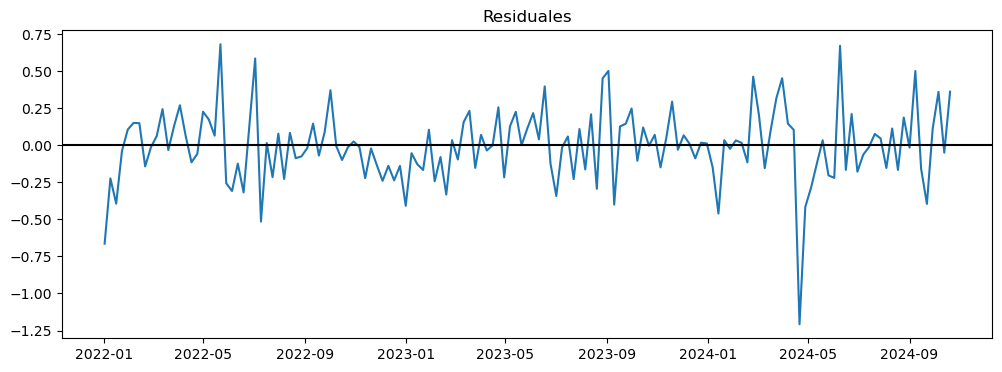

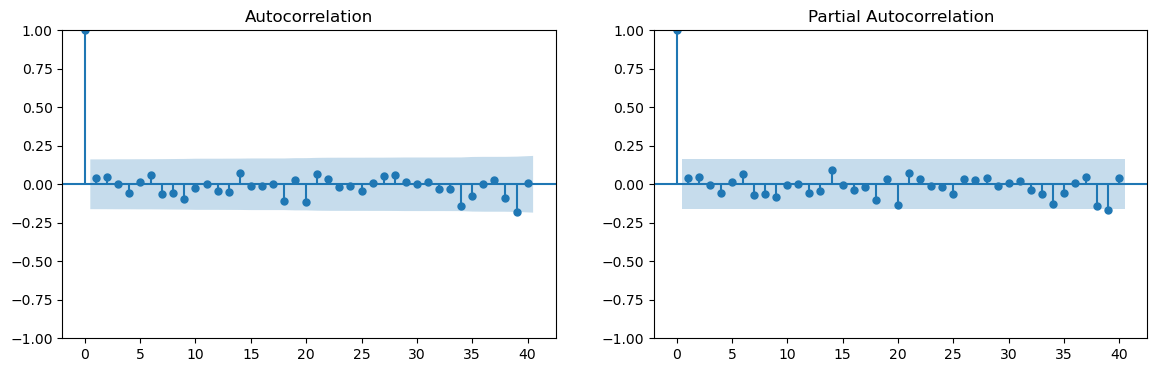

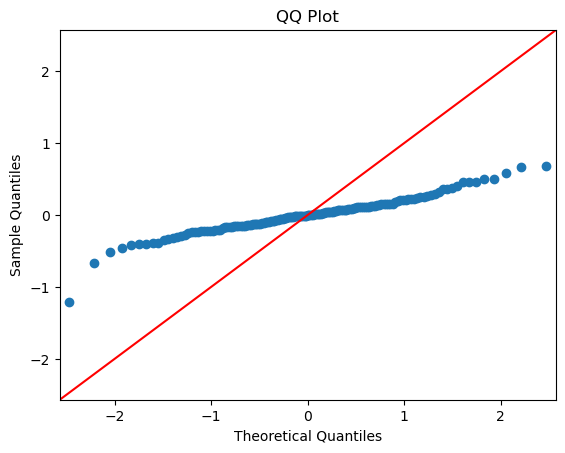

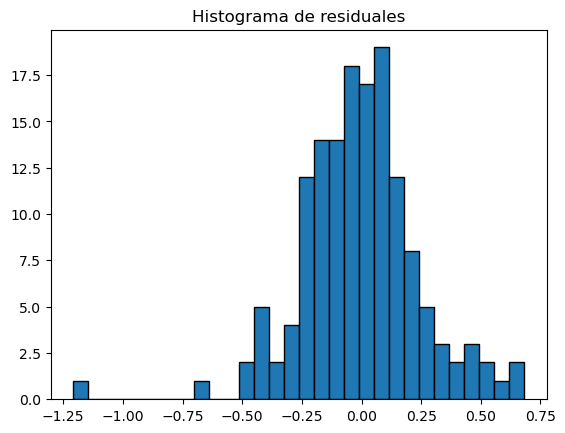

In [56]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_1", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## PM10

In [57]:
#out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM10", y_transform=np.log1p, inverse_transform=np.expm1)
#
#
#for best in [out["best_daily"], out["best_weekly"]]:
#    print("Frecuencia seleccionada:", best["freq"])
#    print("AIC:", best["AIC"])
#    print("MAE:", best["MAE"])
#    print("RMSE:", best["RMSE"])
#    print("MAPE:", best["MAPE"])
#    print("R2:", best["R2"])
#    print("LjungBox_p:", best["LjungBox_p"])
#    print("JarqueBera_p:", best["JarqueBera_p"])
#    print("best_order:", best["best_order"])
#    print(best["coef_table"])
#    print(best["results"].summary())
#
#plot_diagnostics(best)

## PM2.5

In [58]:
#out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "PM2.5", y_transform=None, inverse_transform=None)
#
#
#for best in [out["best_daily"], out["best_weekly"]]:
#    print("Frecuencia seleccionada:", best["freq"])
#    print("AIC:", best["AIC"])
#    print("MAE:", best["MAE"])
#    print("RMSE:", best["RMSE"])
#    print("MAPE:", best["MAPE"])
#    print("R2:", best["R2"])
#    print("LjungBox_p:", best["LjungBox_p"])
#    print("JarqueBera_p:", best["JarqueBera_p"])
#    print("best_order:", best["best_order"])
#    print(best["coef_table"])
#    print(best["results"].summary())
#
#plot_diagnostics(best)

## Y_3

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 971.9359514116369
MAE: 0.7006542404388987
RMSE: 0.8073235092221991
MAPE: 915.0726061431268
R2: -1.9964828250174245
LjungBox_p: 0.5785908069437353
JarqueBera_p: 0.0
best_order: (5, 1, 5)
  Variable      Coef  AbsImpact    Pvalue
0     TOUT  0.156657   0.156657  0.000016
3      PRS -0.102306   0.102306  0.000049
1       RH -0.064606   0.064606  0.000278
2       SR  0.030579   0.030579  0.264612
                               SARIMAX Results                                
Dep. Variable:                    Y_3   No. Observations:                 1021
Model:               SARIMAX(5, 1, 5)   Log Likelihood                -470.968
Date:                Fri, 05 Dec 2025   AIC                            971.936
Time:                        12:56:06   BIC                           1045.761
Sample:                    01-01-2022   HQIC                           999.976
                         - 10-17-2024                                         
Covariance Typ

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


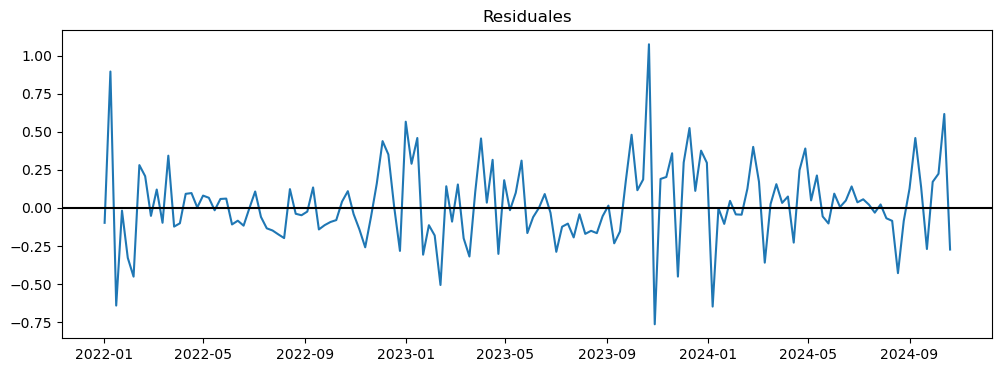

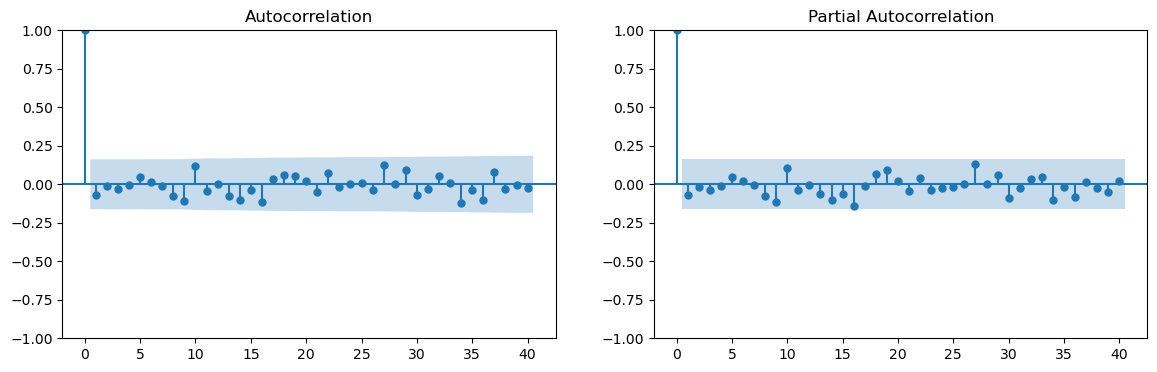

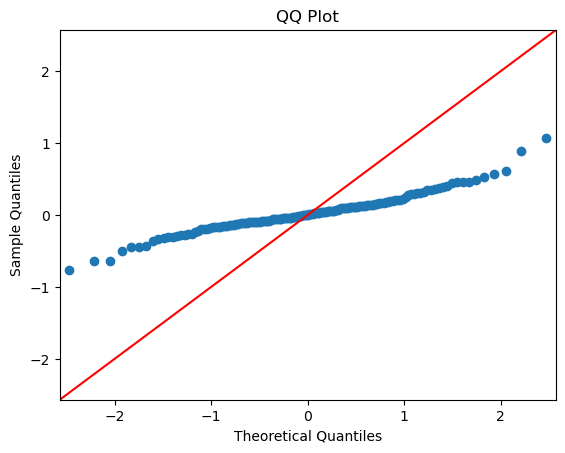

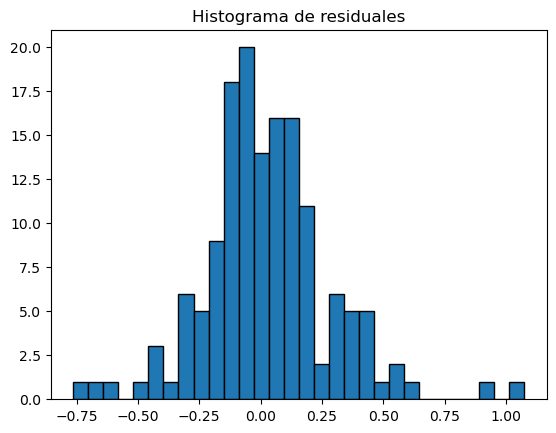

In [59]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_3", y_transform=None, inverse_transform=None)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)

## Y_4

/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/gabrielvas/miniforge3/envs/data_science_arm64/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warning

Frecuencia seleccionada: Diario
AIC: 510.096182643043
MAE: 3.4672833864353
RMSE: 6.607224610720063
MAPE: 35.968056274618455
R2: -0.014633358468098212
LjungBox_p: 0.997734355129308
JarqueBera_p: 6.5447957166747185e-46
best_order: (4, 1, 5)
  Variable      Coef  AbsImpact        Pvalue
2       SR  0.123886   0.123886  9.970832e-10
0     TOUT  0.017901   0.017901  5.119110e-01
3      PRS -0.007100   0.007100  7.423503e-01
1       RH  0.001855   0.001855  9.013250e-01
                               SARIMAX Results                                
Dep. Variable:                    Y_4   No. Observations:                 1021
Model:               SARIMAX(4, 1, 5)   Log Likelihood                -241.048
Date:                Fri, 05 Dec 2025   AIC                            510.096
Time:                        12:56:41   BIC                            578.999
Sample:                    01-01-2022   HQIC                           536.267
                         - 10-17-2024                    

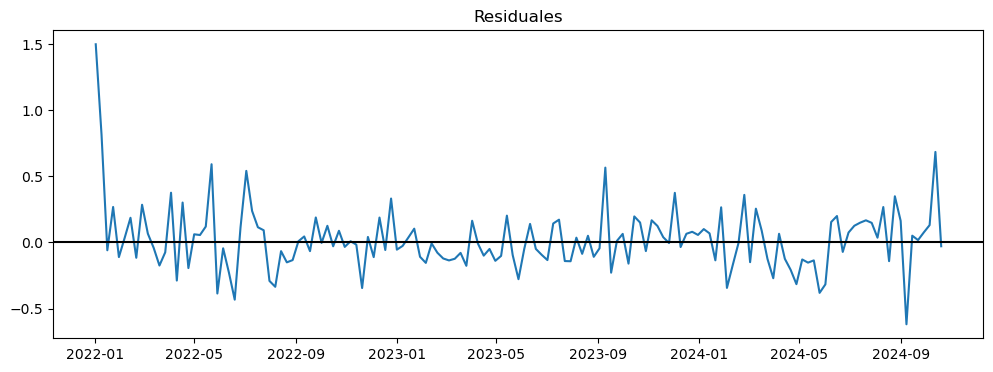

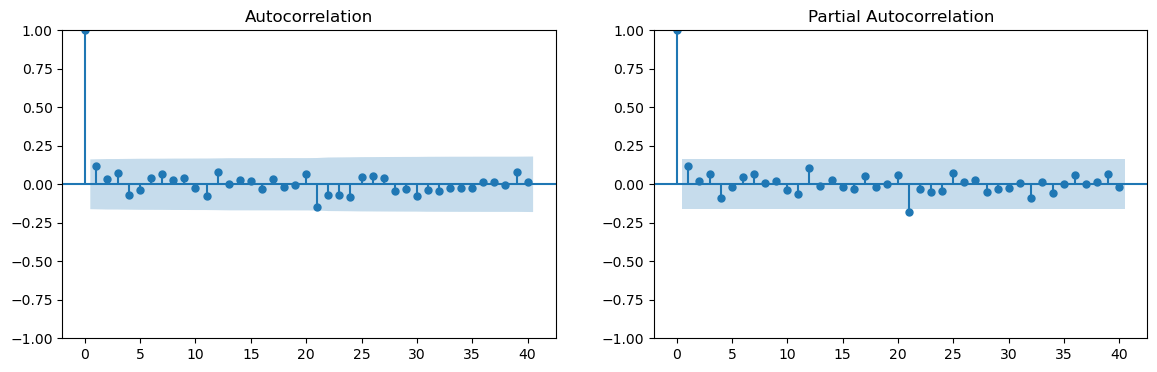

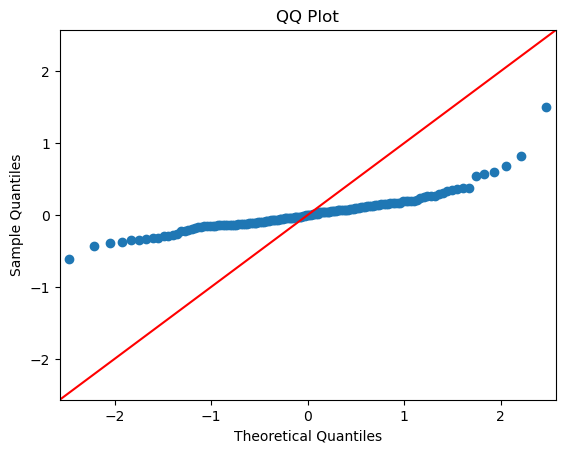

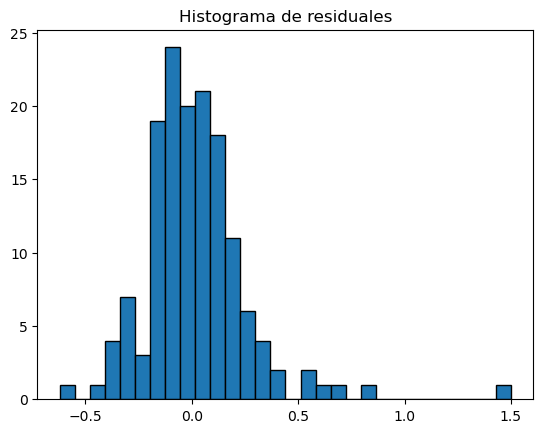

In [60]:
out = fit_best_sarimax(df_Y_diario, df_Y_semanal, "Y_4", y_transform=np.log1p, inverse_transform=np.expm1)


for best in [out["best_daily"], out["best_weekly"]]:
    print("Frecuencia seleccionada:", best["freq"])
    print("AIC:", best["AIC"])
    print("MAE:", best["MAE"])
    print("RMSE:", best["RMSE"])
    print("MAPE:", best["MAPE"])
    print("R2:", best["R2"])
    print("LjungBox_p:", best["LjungBox_p"])
    print("JarqueBera_p:", best["JarqueBera_p"])
    print("best_order:", best["best_order"])
    print(best["coef_table"])
    print(best["results"].summary())

plot_diagnostics(best)